# Proyecto de Analítica Predictiva para Ventas e Inventarios

## Samsung Innovation Campus - Hackathon
### Equipo: `Falta ";"`

### Integrantes
- Miguel Angel Alfonso Saavedra

### Metodología Implementada: ASUM-DM

# 1. Introducción y Contexto del Problema

Aqui se realizará la contextualización de la empresa y su problema para dar pie a la idea de lo que se quiere lograr con los datos.

### Contextualización

La empresa dispone de información histórica relacionada con las ventas e inventarios de sus productos distribuidos a diferentes clientes. Sin embargo, actualmente estos datos no están siendo aprovechados de forma estratégica para identificar patrones de comportamiento, apoyar la toma de decisiones o anticipar escenarios futuros del negocio.

El uso de analítica predictiva permitiría transformar la información histórica en conocimiento útil para las áreas operativas y comerciales. Por ejemplo, anticipar incrementos en la demanda de determinados productos permitiría ajustar oportunamente los niveles de inventario y reducir riesgos de desabastecimiento. De igual manera, identificar disminuciones en el volumen de compra de ciertos clientes facilitaría la implementación de estrategias comerciales preventivas.

Bajo este contexto, surge la necesidad de mejorar el aprovechamiento de la información disponible mediante herramientas analíticas que permitan comprender el comportamiento de las ventas, detectar patrones relevantes y estimar tendencias futuras.

Por esta razón, el área encargada plantea el siguiente problema de negocio:

`Actualmente la empresa cuenta con información histórica de ventas e inventarios, pero no dispone de herramientas analíticas predictivas que apoyen la planeación comercial y operativa. Esta limitación dificulta anticipar fluctuaciones en la demanda, optimizar los niveles de inventario y reducir errores en la estimación de ventas futuras.`

Con el fin de abordar esta problemática, a continuación se realizará un análisis de los datos históricos para identificar comportamientos relevantes y desarrollar modelos que permitan estimar tendencias futuras asociadas a las ventas y al inventario.

# 2. Comprensión del Negocio

Procedemos en esta sección a realizar el análisis del negocio en pro de explicar los objetivos de negocio para este proyecto. Adicionalmente se traducira las metas del negocio desde una perspectiva análitica, esto con el fin de relacionar ambas partes y generar las respectivas hipotesis a probar.


#### Negocio

Actualmente la empresa cuenta con información histórica relacionada con ventas e inventarios de productos comercializados a diferentes clientes. No obstante, esta información aún no está siendo utilizada de manera analítica para apoyar procesos de planeación, abastecimiento y toma de decisiones comerciales.

Debido a esta situación, surge la necesidad de analizar los datos disponibles con el propósito de identificar patrones relevantes, comprender el comportamiento de la demanda y desarrollar modelos predictivos que permitan estimar el comportamiento futuro de indicadores clave asociados a ventas e inventario.

A partir de este contexto, el proyecto busca construir una solución analítica que contribuya a mejorar la capacidad de respuesta del negocio frente a cambios en la demanda y posibles riesgos operativos.


*`Objetivos Estrátegicos`*

- Reducir el error en la estimación de ventas futuras.

- Mejorar la capacidad de anticipar cambios en la demanda de productos.

- Fortalecer la planeación de inventario y abastecimiento.

- Apoyar la toma de decisiones comerciales mediante análisis basados en datos.

---------------------------------------------------------------------------
*`Indicadores de Interés`*

Los principales indicadores que se desean analizar o estimar son:

- Ventas futuras por producto y cliente.

- Volumen esperado de ventas en próximos periodos.

- Productos con mayor o menor demanda esperada.

- Posibles riesgos de desabastecimiento según la demanda proyectada.

- Tendencias temporales en ventas e inventarios.

Adicionalmente, los resultados podrán presentarse mediante visualizaciones y dashboards interactivos que faciliten la interpretación de la información obtenida.

---------------------------------------------------------------------------

*`Objetivos Análiticos`*

- Analizar el comportamiento temporal de las ventas por producto y cliente.

- Identificar patrones, tendencias y anomalías en los datos históricos.

- Explorar la relación entre temporalidad, demanda e inventario.

- Aplicar medidas estadísticas y correlacionales para comprender el comportamiento de las variables.

- Detectar factores asociados a variaciones en la demanda de productos.

- Desarrollar modelos predictivos orientados a estimar ventas futuras.

- Identificar posibles riesgos de desabastecimiento en determinados periodos.

# 3. Importación de Librerias

En la sección actual se importarán todas las librerias necesarias para realizar todas las tareas desde el EDA hasta la realización de modelos de predicción.

In [ ]:
#si se tiene problemas con alguna libreria, se ejecuta la libreria con la que tenga problemas, pero si ejecut todas 
%pip install scikit-learn
%pip install pandas
%pip install numpy
%pip install plotly
%pip install seaborn
%pip install scipy
%pip install xgboost

In [58]:
#Si no se encuentra el paquete, se instala con el comando %pip
#%pip install scikit-learn
#%pip install seaborn
#%pip install --upgrade nbformat

import pandas as pd
import numpy as np

# Visualización
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Estadística
from scipy.stats import pearsonr
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import f_oneway
import seaborn as sns
from scipy.stats import chi2_contingency


# 4. Carga de Dataframes

Se cargan los dataframes.

In [9]:
df_2023 = pd.read_csv("../data/2023.csv")
df_2024 = pd.read_csv("../data/2024.csv")
df_2025 = pd.read_csv("../data/2025.csv")

# 5. Comprensión Inicial de los Datos

En esta sección se realizará una exploración inicial del dataframe para comprender su estructura, dimensiones, tipos de datos y posibles desafíos asociados al análisis.

In [10]:
print("Volumen 2023:")
print(df_2023.shape, "\n")
print("Volumen 2024:")
print(df_2024.shape, "\n")
print("Volumen 2025:")
print(df_2025.shape, "\n")

Volumen 2023:
(43338, 55) 

Volumen 2024:
(37035, 55) 

Volumen 2025:
(25239, 55) 



Se puede denotar que cada dataframe maneja una cantidad significativa de datos. Los tres dataframes manejan la misma cantidad de variables (columnas), sin embargo cada conjunto de datos tiene un número de instancias (filas) diferente. Curiosamente el número total de instancias es inversamente proporcional al pasar lo años, el 2023 siendo el mayor cuenta con 43338 instancias, el 2024 con 37025 y por ultimo el 2025 tiene 25239.

In [11]:
print("COLUMNAS 2023")
print(df_2023.columns)

print("COLUMNAS 2024")
print(df_2024.columns)

print("COLUMNAS 2025")
print(df_2025.columns)

COLUMNAS 2023
Index(['Channel', 'Material Description', 'Category', '202301', '202302',
       '202303', '202304', '202305', '202306', '202307', '202308', '202309',
       '202310', '202311', '202312', '202313', '202314', '202315', '202316',
       '202317', '202318', '202319', '202320', '202321', '202322', '202323',
       '202324', '202325', '202326', '202327', '202328', '202329', '202330',
       '202331', '202332', '202333', '202334', '202335', '202336', '202337',
       '202338', '202339', '202340', '202341', '202342', '202343', '202344',
       '202345', '202346', '202347', '202348', '202349', '202350', '202351',
       '202352'],
      dtype='str')
COLUMNAS 2024
Index(['Channel', 'Material Description', 'Category', '202401', '202402',
       '202403', '202404', '202405', '202406', '202407', '202408', '202409',
       '202410', '202411', '202412', '202413', '202414', '202415', '202416',
       '202417', '202418', '202419', '202420', '202421', '202422', '202423',
       '202424', 

Los tres datasets presentan una estructura consistente con 55 columnas. Las primeras variables corresponden a información categórica del cliente, producto y categoría de negocio, mientras que las columnas restantes representan semanas del año en formato temporal (YYYYWW).


In [12]:
print(df_2023.info())

<class 'pandas.DataFrame'>
RangeIndex: 43338 entries, 0 to 43337
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Channel               43338 non-null  str  
 1   Material Description  43338 non-null  str  
 2   Category              43338 non-null  str  
 3   202301                43338 non-null  int64
 4   202302                43338 non-null  int64
 5   202303                43338 non-null  int64
 6   202304                43338 non-null  int64
 7   202305                43338 non-null  int64
 8   202306                43338 non-null  int64
 9   202307                43338 non-null  int64
 10  202308                43338 non-null  int64
 11  202309                43338 non-null  int64
 12  202310                43338 non-null  int64
 13  202311                43338 non-null  int64
 14  202312                43338 non-null  int64
 15  202313                43338 non-null  int64
 16  202314         

El dataframe del 2023 cumple en que cada variable tiene el tipo de dato correspondiente.

In [13]:
print(df_2024.info())

<class 'pandas.DataFrame'>
RangeIndex: 37035 entries, 0 to 37034
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Channel               37035 non-null  str  
 1   Material Description  37035 non-null  str  
 2   Category              37035 non-null  str  
 3   202401                37035 non-null  int64
 4   202402                37035 non-null  int64
 5   202403                37035 non-null  int64
 6   202404                37035 non-null  int64
 7   202405                37035 non-null  int64
 8   202406                37035 non-null  int64
 9   202407                37035 non-null  int64
 10  202408                37035 non-null  int64
 11  202409                37035 non-null  int64
 12  202410                37035 non-null  int64
 13  202411                37035 non-null  int64
 14  202412                37035 non-null  int64
 15  202413                37035 non-null  int64
 16  202414         

El dataframe del 2024 cumple en que cada variable tiene el tipo de dato correspondiente.

In [14]:
print(df_2025.info())

<class 'pandas.DataFrame'>
RangeIndex: 25239 entries, 0 to 25238
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Channel               25239 non-null  str    
 1   Material Description  25239 non-null  str    
 2   Category              25239 non-null  str    
 3   202501                25239 non-null  str    
 4   202502                25239 non-null  str    
 5   202503                25239 non-null  str    
 6   202504                25239 non-null  str    
 7   202505                25239 non-null  str    
 8   202506                25239 non-null  str    
 9   202507                25239 non-null  str    
 10  202508                25239 non-null  str    
 11  202509                25239 non-null  str    
 12  202510                25239 non-null  str    
 13  202511                25239 non-null  str    
 14  202512                25239 non-null  str    
 15  202513                25239 no

En cambio el 2025 presenta una anomalía con los tipos de datos, ya que bastantes semanas tienen tipo de cadena de texto (string), cuando estos representas las cantidades vendidas en dichas semanas.

Como los tres dataframes manejan la misma estructura se reconocen las siguientes variables:


- `CHANNEL`: Tipo texto Nominal, hace referencia al cliente, entidad o canal que esta realizando la compra de los productos.

- `MATERIAL DESCRIPTION`: Tipo texto Nominal, es el tipo de material o producto que se esta comprando.

- `CATEGORY`: Tipo texto Nominal, se refiere a la categoria en que se encuentra la compra. Sell in (Despacho a los clientes), Cust. Sales (Venta de los clientes del producto) y Channel Inv (Inventario).

- `202XN`: (X = 3 al 5) ( N = 01 al 52) Tipo Numérico Discreta. Representa la cantidad de unidades que se gestionaron en cada semana del año. En total son 52 columnas cada una representado cada semana del año.


In [15]:
df_2023.head()

,Channel,Material Description,Category,202301,202302,202303,202304,202305,202306,202307,...,202343,202344,202345,202346,202347,202348,202349,202350,202351,202352
0,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Sell-in,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Cust. Sales,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Channel Inv.,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Sell-in,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Cust. Sales,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


El dataset combina variables categóricas con múltiples columnas semanales asociadas al comportamiento temporal de ventas e inventario. Debido a que la información temporal se encuentra distribuida en formato ancho, será necesaria una transformación a formato longitudinal para facilitar el análisis exploratorio y el modelado predictivo.

Las semanas se encuentran `representadas como columnas independientes`, por lo que se aplicará una transformación estructural hacia formato longitudinal para centralizar la variable temporal en una única columna.

Posterior a esto hacemos un análisis a la presencia de datos nulos, NA's, anomalos o duplicados.

In [16]:
print("Datos nulos 2023:")
print(df_2023.isnull().sum().sum(),"\n")

print("Datos nulos 2024:")
print(df_2024.isnull().sum().sum(), "\n")

print("Datos nulos 2025:")
print(df_2025.isnull().sum().sum(), "\n")

Datos nulos 2023:
0 

Datos nulos 2024:
0 

Datos nulos 2025:
0 



Ninguno de los conjunto de datos presenta datos nulos

In [17]:
print("Datos duplicados 2023:")
print(df_2023.duplicated().sum(), "\n")

print("Datos duplicados 2024:")
print(df_2024.duplicated().sum(), "\n")

print("Datos duplicados 2025:")
print(df_2025.duplicated().sum())

Datos duplicados 2023:
1741 

Datos duplicados 2024:
1620 

Datos duplicados 2025:
734


Cada año presenta una cantidad considerable de filas duplicadas, las cuales se trataran en la sección de transformación.

Posteriormente se revisa la cantidad de clientes/canales unicos que tiene cada dataframe. Adicionalmente tambien se ve la cantidad de productos unicos que se gestionaron en cada año.

In [18]:
print("Total de clientes/canales unicos 2023:")
print(df_2023["Channel"].nunique())

print("Total de clientes/canales unicos 2024:")
print(df_2024["Channel"].nunique())

print("Total de clientes/canales unicos 2025:")
print(df_2025["Channel"].nunique())

Total de clientes/canales unicos 2023:
92
Total de clientes/canales unicos 2024:
80
Total de clientes/canales unicos 2025:
74


In [19]:
print("Total de Productos unicos 2023:")
print(df_2023["Material Description"].nunique())

print("Total de Productos unicos 2024:")
print(df_2024["Material Description"].nunique())

print("Total de Productos unicos 2025:")
print(df_2025["Material Description"].nunique())

Total de Productos unicos 2023:
1645
Total de Productos unicos 2024:
1386
Total de Productos unicos 2025:
1159


Tras esto vamos revisar mas a profundidad la variable "Material Description", esto con el fin de desglosarla y obtener lo que esta descripción contiene a modo de obtener un mejor entendimiento de la variable, que se puede analizar de esta y si se puede analizar en partes.

In [20]:
df_2023["Material Description"].str.split(",").str.len().value_counts()

Material Description
4    20955
5    13011
3     6978
6     2274
2       75
1       45
Name: count, dtype: int64

La descripción esta compuesta por palabras que se refieren a diferentes caracteristicas del producto, en efecto `cada caracteristica esta separada por una coma`, llegando a tener desde solo una caracteristica hasta otros a tener 6 caracteristicas.

Usando el ejemplo del producto `"MOBILE,SM-A032M/DS,BLACK,LTC"` se observa que este descripción esta organizado de la siguiente manera: tipo de producto, modelo, color y región. Pero como se observo anteriormente algunos productos tienen mas o menos caracteristicas que este ejemplo.

Por lo que se tomo cada año y se analizo las caracteristicas de cada producto en base al ejemplo y el orden que tenía, pero agregando 2 más que son el maximo, estos son: tipo de producto, modelo, variante, color, region y extra.

In [21]:
split_cols = df_2023["Material Description"].str.split(",", expand=True)
split_cols.columns = [
    "Product_Type",
    "Model",
    "Variant",
    "Color",
    "Region",
    "Extra"
]
print("2023:")
for col in split_cols.columns:
    print(f"\n{col}")
    print(split_cols[col].value_counts().head())

2023:

Product_Type
Product_Type
MOBILE     14043
LED TV      6495
QLED TV     3489
TABLET      2472
OWM         1566
Name: count, dtype: int64

Model
Model
SELACOL        3753
26.5            558
SM-A135M/DS     492
SM-A032M/DS     417
SM-A127M/DS     399
Name: count, dtype: int64

Variant
Variant
BLACK        5028
CO           3738
120V 60HZ    3516
55           2379
KW           2286
Name: count, dtype: int64

Color
Color
COLOMBIA         10992
LTC              10062
COO               5154
UNITED STATES     1419
SETIN             1146
Name: count, dtype: int64

Region
Region
CO           1314
HP            960
TC            321
T             264
UWK10/U50     231
Name: count, dtype: int64

Extra
Extra
R410A    2268
R22         6
Name: count, dtype: int64


In [22]:
split_cols = df_2024["Material Description"].str.split(",", expand=True)
split_cols.columns = [
    "Product_Type",
    "Model",
    "Variant",
    "Color",
    "Region",
    "Extra"
]
print("2024:")
for col in split_cols.columns:
    print(f"\n{col}")
    print(split_cols[col].value_counts().head())

2024:

Product_Type
Product_Type
MOBILE     11328
LED TV      4827
QLED TV     2754
TABLET      2157
OWM         1962
Name: count, dtype: int64

Model
Model
SELACOL        3390
SAMCOL          468
SM-S928B/DS     450
26.5            402
0.8             396
Name: count, dtype: int64

Variant
Variant
120V 60HZ    3900
CO           3807
BLACK        3555
KW           2193
GRAY         2043
Name: count, dtype: int64

Color
Color
LTC              9825
COLOMBIA         8469
COO              2580
UNITED STATES    1437
SETIN            1272
Name: count, dtype: int64

Region
Region
HP           1194
CO            999
TC            210
QWK30/Q50     198
QWK30/Q55     189
Name: count, dtype: int64

Extra
Extra
R410A    1875
R32       318
Name: count, dtype: int64


In [23]:
split_cols = df_2025["Material Description"].str.split(",", expand=True)
split_cols.columns = [
    "Product_Type",
    "Model",
    "Variant",
    "Color",
    "Region",
    "Extra"
]
print("2025:")
for col in split_cols.columns:
    print(f"\n{col}")
    print(split_cols[col].value_counts().head())

2025:

Product_Type
Product_Type
MOBILE     7689
LED TV     3207
QLED TV    1863
TABLET     1422
OWM        1314
Name: count, dtype: int64

Model
Model
SELACOL        2208
SAMCOL          456
SM-A055M/DS     333
SM-S721B/DS     321
SM-S938B/DS     321
Name: count, dtype: int64

Variant
Variant
120V 60HZ    2733
CO           2625
BLACK        2340
KW           1563
GRAY         1428
Name: count, dtype: int64

Color
Color
LTC              6570
COLOMBIA         5685
COO              1752
UNITED STATES     993
SETIN             819
Name: count, dtype: int64

Region
Region
CO           795
HP           771
QWK30/Q50    147
UWM00/U40    147
UWS41/U50    147
Name: count, dtype: int64

Extra
Extra
R410A    1197
R32       369
Name: count, dtype: int64


Al analizar los resultados de la columna "Material Description" se puede concluir que el dataframe no sigue una ontología uniforme de producto, lo cual es completamente normal en datos empresariales.

Sin embargo en cada descripción se cumple algo, la primera caracteristica siempre corresponde al tipod de producto. Entonces conservarlo como una columna separada puede ser viable.

En la transformación se recomienda manejar un dataframe con una estructura con formato longitudinal, esto con el fin de normalizar y manejar una columna con la información de la semana y otra deñ año.

# 6. Integración y Transformación de Datos

En esta sección se realizan las transformaciones necesarias al conjunto de datos para que sea mas facil de trabajar, analizar y procesar.

Iniciamos con eliminar las `filas duplicadas`en cada dataframe.

In [24]:
df_2023c = df_2023.drop_duplicates()
df_2024c = df_2024.drop_duplicates()
df_2025c = df_2025.drop_duplicates()

In [25]:
print("Datos duplicados 2023:")
print(df_2023c.duplicated().sum(), "\n")

print("Datos duplicados 2024:")
print(df_2024c.duplicated().sum(), "\n")

print("Datos duplicados 2025:")
print(df_2025c.duplicated().sum())

Datos duplicados 2023:
0 

Datos duplicados 2024:
0 

Datos duplicados 2025:
0


Tras esto se corrige el tipo de dato de las columnas de las semanas del año 2025, teniendo en cuenta que tiene una estructura en que la "," representa el separador de miles y que tienen un espacio en blanco al final de algunos valores que pueden interferir con el parseo. Para finalmente transformar los datos de las columnas al formato numérico de forma segura.

In [26]:
week_columns = df_2025c.columns[3:]

df_2025c[week_columns] = (
    df_2025c[week_columns]
    .replace(',', '', regex=True)
    .replace(' ', '', regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

Al tener todos los datasets listos para trabajar creamos un método, el cual tiene el objetivo de que convierta las variables de las semanas en parte de las instancias y adicionalmente que cree una columna nueva nombrada "Units" que tome la cantidad de unidades que estaba en cada columna.

Esto aumentara significativamente el número de cada instancia, ya que si cada fila tenia información relacionada con cada columna de semana, ahora se transforma a que cada fila de dicho producto tenga la misma fila pero con una semana diferente.

In [27]:
def transform_date(df):
    df = df.melt(id_vars=["Channel", "Material Description", "Category"], var_name="Semana", value_name="Units")
    df["Year"] = df["Semana"].str[:4]
    df["Year"] = df["Year"].astype(int)
    df["Week"] = df["Semana"].str[4:]
    df["Week"] = df["Week"].astype(int)
    df["Units"] = df["Units"].astype(int)
    df = df.drop("Semana", axis=1)
    return df

In [28]:
df_2023t = transform_date(df_2023c)
df_2024t = transform_date(df_2024c)
df_2025t = transform_date(df_2025c)
df_2023t.head()

,Channel,Material Description,Category,Units,Year,Week
0,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Sell-in,0,2023,1
1,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Cust. Sales,0,2023,1
2,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Channel Inv.,0,2023,1
3,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Sell-in,0,2023,1
4,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Cust. Sales,0,2023,1


Los valores iguales a cero fueron conservados debido a que representan semanas sin movimiento comercial, comportamiento esperado en series temporales de ventas e inventario.

Tras realizar la transformación mencionada se observa que ahora muestran los productos en orden pero desde la semana uno del año vigente. Pero esto tambien puede generar datos duplicados los cuales tambien se trataran inmediatamente en la siguiente celda.

In [29]:
print("Datos duplicados 2023 transformado:")
print(df_2023t.duplicated().sum(), "\n")
df_2023t = df_2023t.drop_duplicates()

print("Datos duplicados 2024 transformado:")
print(df_2024t.duplicated().sum(), "\n")
df_2024t = df_2024t.drop_duplicates()

print("Datos duplicados 2025 transformado:")
print(df_2025t.duplicated().sum())
df_2025t = df_2025t.drop_duplicates()

Datos duplicados 2023 transformado:
139783 

Datos duplicados 2024 transformado:
141318 

Datos duplicados 2025 transformado:
113736


Tras trasnformar cada dataframe de forma separada se puede proceder a unirlos. Para posteriormente ver si tienen datos nulos o duplicados, asi como ver la información de las variables y el número de instancias.

In [30]:
df_total = pd.concat([df_2023t, df_2024t, df_2025t], ignore_index=True)
print(df_total.info())
print("Total de datos nulos: ", df_total.isnull().sum().sum())
print("Total de datos duplicados : ", df_total.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4884047 entries, 0 to 4884046
Data columns (total 6 columns):
 #   Column                Dtype
---  ------                -----
 0   Channel               str  
 1   Material Description  str  
 2   Category              str  
 3   Units                 int64
 4   Year                  int64
 5   Week                  int64
dtypes: int64(3), str(3)
memory usage: 223.6 MB
None
Total de datos nulos:  0
Total de datos duplicados :  0


In [31]:
df_total.head()

,Channel,Material Description,Category,Units,Year,Week
0,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Sell-in,0,2023,1
1,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Cust. Sales,0,2023,1
2,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Channel Inv.,0,2023,1
3,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Sell-in,0,2023,1
4,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Cust. Sales,0,2023,1


In [32]:
df_total.tail()

,Channel,Material Description,Category,Units,Year,Week
4884042,CUSTOMER90,"MOBILE,SM-S938B/DS,BLACK,LTC",Cust. Sales,0,2025,52
4884043,CUSTOMER90,"MOBILE,SM-S938B/DS,BLACK,LTC",Channel Inv.,0,2025,52
4884044,CUSTOMER90,"TABLET,SM-X205,GRAY,COO",Sell-in,0,2025,52
4884045,CUSTOMER90,"TABLET,SM-X205,GRAY,COO",Cust. Sales,0,2025,52
4884046,CUSTOMER90,"TABLET,SM-X205,GRAY,COO",Channel Inv.,0,2025,52


Tras concatenar los dataframes de cada año en un datafrane general, se puede evidenciar que se unieron sin ningun problema, adicionalmente que los columnas mantienen el tipo de dato adecuado, esto tambien se ve al obtener algunas filas del dataframe.

Tras combinar los dataframes, ahora se puede extraer el tipo de producto de la descripción del material.

In [33]:
df_total['Product_Type'] = (df_total['Material Description'].str.split(',').str[0])
df_total

,Channel,Material Description,Category,Units,Year,Week,Product_Type
0,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Sell-in,0,2023,1,MOBILE
1,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Cust. Sales,0,2023,1,MOBILE
2,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Channel Inv.,0,2023,1,MOBILE
3,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Sell-in,0,2023,1,MOBILE
4,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Cust. Sales,0,2023,1,MOBILE
...,...,...,...,...,...,...,...
4884042,CUSTOMER90,"MOBILE,SM-S938B/DS,BLACK,LTC",Cust. Sales,0,2025,52,MOBILE
4884043,CUSTOMER90,"MOBILE,SM-S938B/DS,BLACK,LTC",Channel Inv.,0,2025,52,MOBILE
4884044,CUSTOMER90,"TABLET,SM-X205,GRAY,COO",Sell-in,0,2025,52,TABLET
4884045,CUSTOMER90,"TABLET,SM-X205,GRAY,COO",Cust. Sales,0,2025,52,TABLET


`La variable Material Description fue descompuesta para mejorar la interpretabilidad y el análisis segmentado de productos.`

La variable Category representa diferentes tipos de movimiento comercial relacionados con ventas e inventario:

- Sell-in
- Cust. Sales
- Channel Inv.

Inicialmente estos valores se encontraban almacenados como registros independientes, lo que generaba múltiples filas para un mismo producto y semana.

Sin embargo, desde una perspectiva analítica y predictiva, resulta más adecuado representar cada categoría como una variable numérica independiente. Esto permite consolidar en una sola fila toda la información comercial asociada a un producto en una semana determinada.

Debido a esto, se realizará una transformación tipo pivot para convertir los valores de Category en columnas:

- Sell_in
- Cust_Sales
- Channel_Inv

De esta manera, el dataset queda estructurado para facilitar análisis temporales, correlaciones y modelos predictivos posteriores.

In [34]:
df_total = df_total.pivot_table(index=["Channel","Product_Type","Material Description","Week","Year"],columns="Category",values="Units",aggfunc="sum").reset_index()
print(df_total.info())
print("Total de datos nulos: ", df_total.isnull().sum().sum())
print("Total de datos duplicados : ", df_total.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1536652 entries, 0 to 1536651
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype
---  ------                --------------    -----
 0   Channel               1536652 non-null  str  
 1   Product_Type          1536652 non-null  str  
 2   Material Description  1536652 non-null  str  
 3   Week                  1536652 non-null  int64
 4   Year                  1536652 non-null  int64
 5   Channel Inv.          1536652 non-null  int64
 6   Cust. Sales           1536652 non-null  int64
 7   Sell-in               1536652 non-null  int64
dtypes: int64(5), str(3)
memory usage: 93.8 MB
None
Total de datos nulos:  0
Total de datos duplicados :  0


In [35]:
df_total.columns.name = None
df_total = df_total.rename(columns={
    "Sell-in": "Sell_in",
    "Cust. Sales": "Cust_Sales",
    "Channel Inv.": "Channel_Inv"
})
df_total.head()

,Channel,Product_Type,Material Description,Week,Year,Channel_Inv,Cust_Sales,Sell_in
0,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",1,2023,0,0,0
1,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",2,2023,0,0,0
2,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",3,2023,0,0,0
3,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",4,2023,0,0,0
4,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",5,2023,0,0,0


Se crea una nueva columna "Produc Type", que viene de la primera caracteristica de "Material Description". Ahora se puede organizar un poco el dataframe para que se vea mas organizado el orden las variables.

In [36]:
df_total = df_total.reindex(columns=['Channel',  'Product_Type', 'Material Description', 'Week', 'Year', 'Sell_in', 'Cust_Sales', 'Channel_Inv'])
df_total.head()

,Channel,Product_Type,Material Description,Week,Year,Sell_in,Cust_Sales,Channel_Inv
0,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",1,2023,0,0,0
1,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",2,2023,0,0,0
2,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",3,2023,0,0,0
3,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",4,2023,0,0,0
4,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",5,2023,0,0,0


In [37]:
df_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 1536652 entries, 0 to 1536651
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype
---  ------                --------------    -----
 0   Channel               1536652 non-null  str  
 1   Product_Type          1536652 non-null  str  
 2   Material Description  1536652 non-null  str  
 3   Week                  1536652 non-null  int64
 4   Year                  1536652 non-null  int64
 5   Sell_in               1536652 non-null  int64
 6   Cust_Sales            1536652 non-null  int64
 7   Channel_Inv           1536652 non-null  int64
dtypes: int64(5), str(3)
memory usage: 93.8 MB


In [38]:
print("\n\n", "Datos nulos:", "\n")
print(df_total.isnull().sum())
print("\n\n", "Datos dupĺicados:")
print(df_total.duplicated().sum())



 Datos nulos: 

Channel                 0
Product_Type            0
Material Description    0
Week                    0
Year                    0
Sell_in                 0
Cust_Sales              0
Channel_Inv             0
dtype: int64


 Datos dupĺicados:
0


Al terminar con el tratamiento de los dataframes, las transformaciones, la unión y su gestión se obtiene un dataframe con 7 variables que corresponden a:


- `CHANNEL`: Tipo texto nominal, hace referencia al cliente, entidad o canal que esta realizando la compra de los productos.
  
- `PRODUCT_TYPE`: Tipo texto nominal, es el tipo de material o producto que se esta comprando.

- `MATERIAL DESCRIPTION`: Tipo texto nominal, es una linea de texto que contiene varias caracteristicas del producto.

- `WEEK`: Tipo numérico discreta. Representa la semana del año en que se realizo la compra. Va desde la semana 1 hasta la 52 de su respectivo año.

- `YEAR`: Tipo numérico discreta. Representa el año en que se realizo la compra. Va desde el 2023 hasta el 2025.
  
- `SELL_IN`: Variable numérica discreta, representa la cantidad de unidades despachadas o vendidas desde la empresa hacia el cliente o canal de distribución durante una semana determinada.

- `CUST_SALES`: Variable numérica discreta, representa la cantidad de unidades vendidas por el cliente final o distribuidor durante una semana específica. Refleja el comportamiento real de la demanda del mercado.

- `CHANNEL_INVS`: Variable numérica discreta, representa la cantidad de unidades registradas como inventario disponible en el canal o cliente durante una semana determinada.



Tras terminar con esta fase se guardara el dataframe obtenido para utilizar este como insumo principal de aqui en adelante en las siguientes fases.

In [39]:
df_total.to_csv("../data/dataset_transformado.csv", index=False)

# 7. Limpieza y Preprocesamiento

Aqui se tratan los datos nulos, valores atipicos, tipos de datos, inconsistencias y normalización si aplica para que no afecte el análisis más adelante.

In [2]:
## ADVERTENCIA: Comentar esta celda si NO está trabajando dentro de Google Colaboratory
import os
from google.colab import drive
drive.mount('/content/drive')  # AVISO: conectar desde el dueño directo del drive (quien tenga MyDrive)

os.getcwd()
os.chdir("/content/drive/MyDrive")  # AVISO: no conecta bien a Shared with me
os.getcwd()

Mounted at /content/drive


'/content/drive/MyDrive'

In [ ]:
df_total = pd.read_csv('dataset_transformado.csv', header='infer')

### 7.1 Carga del Dataset Transformado

Debido al tamaño del dataframe obtenido al final de la transformación (más de 4.8 millones de registros), se alamacenó una versión procesada del dataframe como ya se menciono con el fin de optimizar tiempos de ejecución y facilitar las etapas posteriores del análisis.

In [40]:
df_total = pd.read_csv("../data/dataset_transformado.csv")

### 7.2 Verificación General del Dataset

Tras importar el archivo generado en la transformación se revisará la calidad de los datos. Desde la presencia de nulos y duplicados, hasta los outliers presentes en el datos y que los tipos de datos correspondan a la variable adecuada.

In [41]:
print("\n\n", "Datos nulos:", "\n")
print(df_total.isnull().sum())



 Datos nulos: 

Channel                 0
Product_Type            0
Material Description    0
Week                    0
Year                    0
Sell_in                 0
Cust_Sales              0
Channel_Inv             0
dtype: int64


No se presenta ningún dato nulo o Nan en el conjunto.

In [42]:
print("Datos dupĺicados:")
print(df_total.duplicated().sum())

Datos dupĺicados:
0


Tampoco se tiene  la presencia de datos o filas duplicadas en el dataframe

In [43]:
print(df_total.info())

<class 'pandas.DataFrame'>
RangeIndex: 1536652 entries, 0 to 1536651
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype
---  ------                --------------    -----
 0   Channel               1536652 non-null  str  
 1   Product_Type          1536652 non-null  str  
 2   Material Description  1536652 non-null  str  
 3   Week                  1536652 non-null  int64
 4   Year                  1536652 non-null  int64
 5   Sell_in               1536652 non-null  int64
 6   Cust_Sales            1536652 non-null  int64
 7   Channel_Inv           1536652 non-null  int64
dtypes: int64(5), str(3)
memory usage: 93.8 MB
None


No se presenta ninguna discordancia en las variables del dataframe con sus tipo de datos correspondientes.

A pesar de no encontrarse valores nulos ni duplicados, las variables numéricas asociadas a ventas, inventario y despacho presentan una distribución altamente dispersa, con una gran concentración de valores iguales a cero, presencia de registros negativos y algunos movimientos extremadamente altos.

Debido a esto, se analizará el comportamiento estadístico de las variables `SELL_IN_UNITS`, `CUST_SALES_UNITS` y `CHANNEL_INV_UNITS`, con el fin de determinar si dichos valores corresponden a comportamientos reales del negocio o a posibles inconsistencias en los datos.


### 7.3 Análisis de Variables Numéricas

#### 7.3.1 Estadísticos descriptivos

En este apartado se analizarán las variables numéricas Sell_in, Cust_Sales y Channel_Inv, las cuales representan los principales indicadores operativos y comerciales del negocio.
Estas variables serán fundamentales para las etapas posteriores de análisis exploratorio, ingeniería de características y modelado predictivo.

In [44]:
df_total[["Sell_in","Cust_Sales","Channel_Inv"]].describe()

,Sell_in,Cust_Sales,Channel_Inv
count,1.536652e+06,1.536652e+06,1.536652e+06
mean,5.808124e+00,5.887761e+00,4.878304e+01
std,9.626034e+01,5.870601e+01,3.774563e+02
min,-3.997000e+03,-1.517000e+03,-5.230000e+02
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,6.000000e+00
max,2.751800e+04,1.716200e+04,4.348400e+04


In [45]:
df_total[["Sell_in","Cust_Sales","Channel_Inv"]].describe(percentiles=[0.90,0.95,0.99,0.999])

,Sell_in,Cust_Sales,Channel_Inv
count,1.536652e+06,1.536652e+06,1.536652e+06
mean,5.808124e+00,5.887761e+00,4.878304e+01
std,9.626034e+01,5.870601e+01,3.774563e+02
min,-3.997000e+03,-1.517000e+03,-5.230000e+02
90%,0.000000e+00,4.000000e+00,5.200000e+01
95%,1.000000e+00,1.500000e+01,1.430000e+02
99%,1.000000e+02,1.140000e+02,1.000000e+03
99.9%,1.078698e+03,7.540000e+02,5.045396e+03
max,2.751800e+04,1.716200e+04,4.348400e+04


In [46]:
df_total[["Sell_in","Cust_Sales","Channel_Inv"]].describe(percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

,Sell_in,Cust_Sales,Channel_Inv
count,1.536652e+06,1.536652e+06,1.536652e+06
mean,5.808124e+00,5.887761e+00,4.878304e+01
std,9.626034e+01,5.870601e+01,3.774563e+02
min,-3.997000e+03,-1.517000e+03,-5.230000e+02
10%,0.000000e+00,0.000000e+00,0.000000e+00
20%,0.000000e+00,0.000000e+00,0.000000e+00
30%,0.000000e+00,0.000000e+00,0.000000e+00
40%,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00
60%,0.000000e+00,0.000000e+00,1.000000e+00


Los estadísticos descriptivos evidencian una distribución altamente dispersa y asimétrica. La presencia masiva de valores iguales a cero genera un comportamiento sparse, mientras que algunos registros extremos elevan considerablemente la desviación estándar y el rango de la variable.

#### 7.3.2 Análisis de Sparsity (Ceros)
<a id = "sparsity"></a>

In [47]:
print("Cantidad de ceros en Sell_in: ", df_total[df_total["Sell_in"] == 0]["Sell_in"].value_counts(), "\n")
print("Cantidad de ceros en Cust_Sales: ", df_total[df_total["Cust_Sales"] == 0]["Cust_Sales"].value_counts(), "\n")
print("Cantidad de ceros en Channel_Inv: ", df_total[df_total["Channel_Inv"] == 0]["Channel_Inv"].value_counts(), "\n")

Cantidad de ceros en Sell_in:  Sell_in
0    1448849
Name: count, dtype: int64 

Cantidad de ceros en Cust_Sales:  Cust_Sales
0    1221492
Name: count, dtype: int64 

Cantidad de ceros en Channel_Inv:  Channel_Inv
0    892804
Name: count, dtype: int64 



In [48]:
zero_pct = {
    "Sell_in": ((df_total["Sell_in"] == 0).mean() * 100),
    "Cust_Sales": ((df_total["Cust_Sales"] == 0).mean() * 100),
    "Channel_Inv": ((df_total["Channel_Inv"] == 0).mean() * 100)
}

for key, value in zero_pct.items():
    print(f"Porcentaje de ceros en {key}: {value:.2f}%")

Porcentaje de ceros en Sell_in: 94.29%
Porcentaje de ceros en Cust_Sales: 79.49%
Porcentaje de ceros en Channel_Inv: 58.10%


In [49]:
non_zero_pct = {
    "Sell_in": ((df_total["Sell_in"] != 0).mean() * 100),
    "Cust_Sales": ((df_total["Cust_Sales"] != 0).mean() * 100),
    "Channel_Inv": ((df_total["Channel_Inv"] != 0).mean() * 100)
}

for key, value in non_zero_pct.items():
    print(f"Porcentaje de NO ceros en {key}: {value:.2f}%")

Porcentaje de NO ceros en Sell_in: 5.71%
Porcentaje de NO ceros en Cust_Sales: 20.51%
Porcentaje de NO ceros en Channel_Inv: 41.90%


Se analizó la proporción de valores iguales a cero en cada una de las variables objetivo del negocio: `Sell_in`, `Cust_Sales` y `Channel_Inv`.

Los resultados muestran un comportamiento sparse en las tres variables, aunque con diferentes niveles de intensidad:

- `Sell_in`: 94.29% de valores iguales a cero.
- `Cust_Sales`: 79.49% de valores iguales a cero.
- `Channel_Inv`: 58.10% de valores iguales a cero.

Este comportamiento es coherente con la naturaleza operacional de los datos comerciales e inventarios, ya que no todas las combinaciones producto-cliente-semana presentan movimientos continuamente.

En el caso de `Sell_in`, la alta proporción de ceros puede explicarse por despachos puntuales o abastecimientos no realizados semanalmente. Por otra parte, `Cust_Sales` presenta una mayor frecuencia de movimientos debido a las ventas realizadas por los clientes finales. Finalmente, `Channel_Inv` muestra la menor cantidad de ceros, lo cual resulta consistente con la persistencia de inventario incluso en semanas sin ventas o despachos.

Debido a esto, los valores iguales a cero no serán considerados errores ni eliminados, ya que representan información relevante sobre el comportamiento real de la operación comercial.


#### 7.3.3 Análisis de Valores Negativos

In [50]:
print("Cantidad de negativos en Sell_in: ", (df_total["Sell_in"] < 0).sum(), "\n")
print("Cantidad de negativos en Cust_Sales: ", (df_total["Cust_Sales"] < 0).sum(), "\n")
print("Cantidad de negativos en Channel_Inv: ", (df_total["Channel_Inv"] < 0).sum(), "\n")


Cantidad de negativos en Sell_in:  4627 

Cantidad de negativos en Cust_Sales:  3920 

Cantidad de negativos en Channel_Inv:  3076 



In [51]:
negative_pct = {
    "Sell_in": ((df_total["Sell_in"] < 0).mean() * 100),
    "Cust_Sales": ((df_total["Cust_Sales"] < 0).mean() * 100),
    "Channel_Inv": ((df_total["Channel_Inv"] < 0).mean() * 100)
}

for key, value in negative_pct.items():
    print(f"Porcentaje de negativos en {key}: {value:.2f}%")

Porcentaje de negativos en Sell_in: 0.30%
Porcentaje de negativos en Cust_Sales: 0.26%
Porcentaje de negativos en Channel_Inv: 0.20%


La presencia de valores negativos en las variables de ventas e inventario no parece corresponder a errores aleatorios. Dentro del contexto operacional del negocio, estos registros pueden asociarse a devoluciones, ajustes logísticos, regularización de inventario, cancelaciones o correcciones contables.

Debido a su posible significado operativo y a su baja proporción respecto al total de registros, estos valores serán conservados para análisis posteriores.

### 7.4 Análisis de Distribución

#### 7.4.1 Sell_in

In [52]:
df_sell_positive = df_total[df_total["Sell_in"] > 0].sample(13000, random_state=42)

In [53]:
golden_number = (1 + np.sqrt(5))/2
fig = px.histogram( df_sell_positive["Sell_in"]
               , width = 900, height=900/golden_number
               , nbins = 100
               , marginal= 'rug'
               , orientation="v"
               ,color_discrete_sequence =["purple"]
               ,title = "Distribución de Sell_in"
                )

fig.update_layout(bargap=0.05)


fig.update_traces(selector=dict(type='histogram'),overwrite=True, opacity=0.6
                  ,  xbins = dict(start = min(df_sell_positive["Sell_in"]), end=max(df_sell_positive["Sell_in"]), size =   np.ptp(np.histogram_bin_edges(df_sell_positive["Sell_in"], bins='auto')[0:2]))
                  , autobinx=False
                  )
fig.show() 

Debido a la alta asimetría de la variable, se aplicará una transformación logarítmica sobre los valores positivos con el objetivo de comprimir el rango de los datos y visualizar con mayor claridad la distribución de los movimientos comerciales.

In [54]:
golden_number = (1 + np.sqrt(5))/2
sample_log = np.log1p(df_sell_positive["Sell_in"])

fig = px.histogram( sample_log
               , width = 900, height=900/golden_number
               , marginal= 'rug'
               , nbins = 80
               , orientation="v"
               ,color_discrete_sequence =["purple"]
               ,title = "Distribución Logarítmica de Sell_in"
               , histnorm='probability density'
                )


fig.update_layout(bargap=0.05)


fig.update_traces(selector=dict(type='histogram'),overwrite=True, opacity=0.6
                  ,  xbins = dict(start = min(sample_log), end=max(sample_log), size =  np.ptp(np.histogram_bin_edges(sample_log, bins='auto')[0:2]))
                  , autobinx=False
                  
                  )

media, desviacion = np.mean(sample_log), np.std(sample_log)
x_curva = np.linspace(min(sample_log), max(sample_log), 200)
y_curva = stats.norm.pdf(x_curva, media, desviacion)

fig.add_trace(
    go.Scatter(
        x=x_curva, 
        y=y_curva, 
        mode='lines', 
        name='Curva Normal',
        line=dict(color='red', width=3)  # Color a juego con tu paleta púrpura
    )
)


fig.show() 


La variable `Sell_in` presenta una fuerte asimetría positiva, caracterizada por una alta concentración de registros en valores bajos y pocos movimientos extremadamente altos. Este comportamiento evidencia un patrón sparse típico en datos transaccionales de despacho.

Los percentiles muestran que la mayoría de observaciones permanecen cercanas a cero, mientras que una pequeña proporción concentra operaciones de gran volumen asociadas a semanas de alta rotación comercial.

La transformación logarítmica permitió visualizar con mayor claridad la dispersión de los valores positivos y reducir el efecto visual de los registros extremos.


#### 7.4.2 Cust_Sales

In [55]:
df_cust_positive = df_total[df_total["Cust_Sales"] > 0].sample(20000, random_state=42)

In [56]:
golden_number = (1 + np.sqrt(5))/2
fig = px.histogram( df_cust_positive["Cust_Sales"]
               , width = 900, height=900/golden_number
               , nbins = 100
               , marginal= 'rug'
               , orientation="v"
               ,color_discrete_sequence =["purple"]
               ,title = "Distribución de Cust_Sales"
                )

fig.update_layout(bargap=0.05)


fig.update_traces(selector=dict(type='histogram'),overwrite=True, opacity=0.6
                  ,  xbins = dict(start = min(df_cust_positive["Cust_Sales"]), end=max(df_cust_positive["Cust_Sales"]), size =   np.ptp(np.histogram_bin_edges(df_cust_positive["Cust_Sales"], bins='auto')[0:2]))
                  , autobinx=False
                  )
fig.show() 

Debido a la alta asimetría de la variable, se aplicará una transformación logarítmica sobre los valores positivos con el objetivo de comprimir el rango de los datos y visualizar con mayor claridad la distribución de los movimientos comerciales.

In [57]:
golden_number = (1 + np.sqrt(5))/2
sample_log = np.log1p(df_cust_positive["Cust_Sales"])

fig = px.histogram( sample_log
               , width = 900, height=900/golden_number
               , marginal= 'rug'
               , nbins = 80
               , orientation="v"
               ,color_discrete_sequence =["purple"]
               ,title = "Distribución Logarítmica de Cust_Sales"
               , histnorm='probability density'
                )


fig.update_layout(bargap=0.05)


fig.update_traces(selector=dict(type='histogram'),overwrite=True, opacity=0.6
                  ,  xbins = dict(start = min(sample_log), end=max(sample_log), size =  np.ptp(np.histogram_bin_edges(sample_log, bins='auto')[0:2]))
                  , autobinx=False
                  
                  )

media, desviacion = np.mean(sample_log), np.std(sample_log)
x_curva = np.linspace(min(sample_log), max(sample_log), 200)
y_curva = stats.norm.pdf(x_curva, media, desviacion)

fig.add_trace(
    go.Scatter(
        x=x_curva, 
        y=y_curva, 
        mode='lines', 
        name='Curva Normal',
        line=dict(color='red', width=3)  # Color a juego con tu paleta púrpura
    )
)


fig.show() 


La variable `Cust_Sales` presenta una distribución fuertemente asimétrica positiva, donde predominan operaciones de bajo volumen y pocos registros concentran ventas considerablemente altas.

A diferencia de `Sell_in`, esta variable presenta una menor proporción de valores iguales a cero, lo cual refleja una mayor frecuencia de movimiento comercial por parte de los clientes.

La transformación logarítmica permitió visualizar con mayor claridad la distribución de las ventas positivas y la presencia de registros extremos asociados a incrementos importantes en la demanda.


#### 7.4.3 Channel_Inv

In [58]:
df_channel_positive = df_total[df_total["Channel_Inv"] > 0].sample(20000, random_state=42)

In [59]:
golden_number = (1 + np.sqrt(5))/2
fig = px.histogram( df_channel_positive["Channel_Inv"]
               , width = 900, height=900/golden_number
               , nbins = 100
               , marginal= 'rug'
               , orientation="v"
               ,color_discrete_sequence =["purple"]
               ,title = "Distribución de Channel_Inv"
                )

fig.update_layout(bargap=0.05)


fig.update_traces(selector=dict(type='histogram'),overwrite=True, opacity=0.6
                  ,  xbins = dict(start = min(df_channel_positive["Channel_Inv"]), end=max(df_channel_positive["Channel_Inv"]), size =   np.ptp(np.histogram_bin_edges(df_channel_positive["Channel_Inv"], bins='auto')[0:2]))
                  , autobinx=False
                  )
fig.show() 

Debido a la alta asimetría de la variable, se aplicará una transformación logarítmica sobre los valores positivos con el objetivo de comprimir el rango de los datos y visualizar con mayor claridad la distribución de los movimientos comerciales.

In [60]:
golden_number = (1 + np.sqrt(5))/2
sample_log = np.log1p(df_channel_positive["Channel_Inv"])

fig = px.histogram( sample_log
               , width = 900, height=900/golden_number
               , marginal= 'rug'
               , nbins = 80
               , orientation="v"
               ,color_discrete_sequence =["purple"]
               ,title = "Distribución Logarítmica de Channel_Inv"
               , histnorm='probability density'
                )


fig.update_layout(bargap=0.05)


fig.update_traces(selector=dict(type='histogram'),overwrite=True, opacity=0.6
                  ,  xbins = dict(start = min(sample_log), end=max(sample_log), size =  np.ptp(np.histogram_bin_edges(sample_log, bins='auto')[0:2]))
                  , autobinx=False
                  
                  )

media, desviacion = np.mean(sample_log), np.std(sample_log)
x_curva = np.linspace(min(sample_log), max(sample_log), 200)
y_curva = stats.norm.pdf(x_curva, media, desviacion)

fig.add_trace(
    go.Scatter(
        x=x_curva, 
        y=y_curva, 
        mode='lines', 
        name='Curva Normal',
        line=dict(color='red', width=3)  # Color a juego con tu paleta púrpura
    )
)


fig.show() 


La variable `Channel_Inv` presenta una distribución asimétrica positiva con una menor concentración de ceros respecto a las demás variables analizadas.

Este comportamiento resulta coherente con la persistencia de inventario incluso en semanas sin ventas o despachos. La mayoría de registros corresponden a niveles bajos o moderados de inventario, aunque existen casos con acumulaciones significativamente superiores.

La transformación logarítmica permitió visualizar con mayor claridad la dispersión de los niveles de inventario positivos y la presencia de registros extremos.


### 7.5 Outliers en Variables Operacionales

#### 7.5.1 Generación de Flags de Valores Extremos

Con el fin de facilitar análisis posteriores y apoyar las etapas de modelado predictivo, se crearán variables binarias que permitan identificar registros con movimientos excepcionalmente altos dentro de cada variable operacional.

Estas flags se construirán utilizando el percentil 99 de cada distribución, permitiendo detectar semanas asociadas a comportamientos atípicos, incrementos extraordinarios de demanda o movimientos logísticos poco frecuentes.


In [61]:
q99_sell = df_total["Sell_in"].quantile(0.99)

df_total["High_Sellin_Flag"] = (
    df_total["Sell_in"] > q99_sell
).astype(int)

q99_cust = df_total["Cust_Sales"].quantile(0.99)

df_total["High_Cust_Flag"] = (
    df_total["Cust_Sales"] > q99_cust
).astype(int)

q99_channel = df_total["Channel_Inv"].quantile(0.99)

df_total["High_Channel_Flag"] = (
    df_total["Channel_Inv"] > q99_channel
).astype(int)

df_total.head()

,Channel,Product_Type,Material Description,Week,Year,Sell_in,Cust_Sales,Channel_Inv,High_Sellin_Flag,High_Cust_Flag,High_Channel_Flag
0,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",1,2023,0,0,0,0,0,0
1,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",2,2023,0,0,0,0,0,0
2,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",3,2023,0,0,0,0,0,0
3,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",4,2023,0,0,0,0,0,0
4,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",5,2023,0,0,0,0,0,0


In [62]:
df_total["Sell_in"].describe(percentiles=[0.90,0.95,0.99,0.999])

count    1.536652e+06
mean     5.808124e+00
std      9.626034e+01
min     -3.997000e+03
90%      0.000000e+00
95%      1.000000e+00
99%      1.000000e+02
99.9%    1.078698e+03
max      2.751800e+04
Name: Sell_in, dtype: float64

In [63]:
print("Cantidad de Sell_in < 0: ", df_total[df_total["Sell_in"]  < 0].value_counts().sum())
print("Cantidad de Sell_in 0: ", df_total[df_total["Sell_in"]  == 0].value_counts().sum())
print("Cantidad de Sell_in 1 -> 1000: ", df_total[(df_total["Sell_in"]  >= 1) & (df_total["Sell_in"]  < 1000)]["Sell_in"].value_counts().sum())
print("Cantidad de Sell_in 1000 -> 5000: ", df_total[(df_total["Sell_in"]  >= 1000) & (df_total["Sell_in"]  < 5000)]["Sell_in"].value_counts().sum())
print("Cantidad de Sell_in 5000 -> 10000: ", df_total[(df_total["Sell_in"]  >= 5000) & (df_total["Sell_in"]  < 10000)]["Sell_in"].value_counts().sum())
print("Cantidad de Sell_in 10000 -> 20000: ", df_total[(df_total["Sell_in"]  >= 10000) & (df_total["Sell_in"]  < 20000)]["Sell_in"].value_counts().sum())
print("Cantidad de Sell_in 20000 -> 30000: ", df_total[(df_total["Sell_in"]  >= 20000) & (df_total["Sell_in"]  < 30000)]["Sell_in"].value_counts().sum())
print("Cantidad de Sell_in > 30000: ", df_total[df_total["Sell_in"]  >= 30000].value_counts().sum())

Cantidad de Sell_in < 0:  4627
Cantidad de Sell_in 0:  1448849
Cantidad de Sell_in 1 -> 1000:  81216
Cantidad de Sell_in 1000 -> 5000:  1880
Cantidad de Sell_in 5000 -> 10000:  68
Cantidad de Sell_in 10000 -> 20000:  11
Cantidad de Sell_in 20000 -> 30000:  1
Cantidad de Sell_in > 30000:  0


In [64]:
positive_sell = df_total[df_total["Sell_in"] > 0]["Sell_in"]

fig = px.box(
    y=np.log1p(positive_sell.sample(10000, random_state=42)),
    title="Boxplot logarítmico Sell_in"
)

fig.show()


La variable `Sell_in` presenta una distribución altamente asimétrica positiva, caracterizada por una gran concentración de valores bajos y pocos registros extremadamente altos.

Los diagramas de caja y percentiles permiten identificar valores alejados de la distribución central, especialmente en semanas donde ocurrieron despachos masivos de productos.

In [65]:
df_total["Cust_Sales"].describe(percentiles=[0.90,0.95,0.99,0.999])

count    1.536652e+06
mean     5.887761e+00
std      5.870601e+01
min     -1.517000e+03
90%      4.000000e+00
95%      1.500000e+01
99%      1.140000e+02
99.9%    7.540000e+02
max      1.716200e+04
Name: Cust_Sales, dtype: float64

In [66]:
print("Cantidad de Cust_Sales < 0: ", df_total[df_total["Cust_Sales"]  < 0].value_counts().sum())
print("Cantidad de Cust_Sales 0: ", df_total[df_total["Cust_Sales"]  == 0].value_counts().sum())
print("Cantidad de Cust_Sales 1 -> 1000: ", df_total[(df_total["Cust_Sales"]  >= 1) & (df_total["Cust_Sales"]  < 1000)]["Cust_Sales"].value_counts().sum())
print("Cantidad de Cust_Sales 1000 -> 5000: ", df_total[(df_total["Cust_Sales"]  >= 1000) & (df_total["Cust_Sales"]  < 5000)]["Cust_Sales"].value_counts().sum())
print("Cantidad de Cust_Sales 5000 -> 10000: ", df_total[(df_total["Cust_Sales"]  >= 5000) & (df_total["Cust_Sales"]  < 10000)]["Cust_Sales"].value_counts().sum())
print("Cantidad de Cust_Sales 10000 -> 20000: ", df_total[(df_total["Cust_Sales"]  >= 10000) & (df_total["Cust_Sales"]  < 20000)]["Cust_Sales"].value_counts().sum())
print("Cantidad de Cust_Sales 20000 -> 30000: ", df_total[(df_total["Cust_Sales"]  >= 20000) & (df_total["Cust_Sales"]  < 30000)]["Cust_Sales"].value_counts().sum())
print("Cantidad de Cust_Sales > 30000: ", df_total[df_total["Cust_Sales"]  >= 30000].value_counts().sum())

Cantidad de Cust_Sales < 0:  3920
Cantidad de Cust_Sales 0:  1221492
Cantidad de Cust_Sales 1 -> 1000:  310292
Cantidad de Cust_Sales 1000 -> 5000:  942
Cantidad de Cust_Sales 5000 -> 10000:  5
Cantidad de Cust_Sales 10000 -> 20000:  1
Cantidad de Cust_Sales 20000 -> 30000:  0
Cantidad de Cust_Sales > 30000:  0


In [67]:
positive_cust = df_total[df_total["Cust_Sales"] > 0]["Cust_Sales"]

fig = px.box(
    y=np.log1p(positive_cust.sample(10000, random_state=42)),
    title="Boxplot logarítmico Cust_Sales"
)

fig.show()


La variable `Cust_Sales` presenta una distribución altamente asimétrica positiva, caracterizada por una gran concentración de valores bajos y pocos registros extremadamente altos.

Los diagramas de caja y percentiles permiten identificar valores alejados de la distribución central, especialmente en semanas donde ocurrieron una alta demanda de productos.

In [68]:
df_total["Channel_Inv"].describe(percentiles=[0.90,0.95,0.99,0.999])

count    1.536652e+06
mean     4.878304e+01
std      3.774563e+02
min     -5.230000e+02
90%      5.200000e+01
95%      1.430000e+02
99%      1.000000e+03
99.9%    5.045396e+03
max      4.348400e+04
Name: Channel_Inv, dtype: float64

In [69]:
print("Cantidad de Channel_Inv < 0: ", df_total[df_total["Channel_Inv"]  < 0].value_counts().sum())
print("Cantidad de Channel_Inv 0: ", df_total[df_total["Channel_Inv"]  == 0].value_counts().sum())
print("Cantidad de Channel_Inv 1 -> 1000: ", df_total[(df_total["Channel_Inv"]  >= 1) & (df_total["Channel_Inv"]  < 1000)]["Channel_Inv"].value_counts().sum())
print("Cantidad de Channel_Inv 1000 -> 5000: ", df_total[(df_total["Channel_Inv"]  >= 1000) & (df_total["Channel_Inv"]  < 5000)]["Channel_Inv"].value_counts().sum())
print("Cantidad de Channel_Inv 5000 -> 10000: ", df_total[(df_total["Channel_Inv"]  >= 5000) & (df_total["Channel_Inv"]  < 10000)]["Channel_Inv"].value_counts().sum())
print("Cantidad de Channel_Inv 10000 -> 20000: ", df_total[(df_total["Channel_Inv"]  >= 10000) & (df_total["Channel_Inv"]  < 20000)]["Channel_Inv"].value_counts().sum())
print("Cantidad de Channel_Inv 20000 -> 30000: ", df_total[(df_total["Channel_Inv"]  >= 20000) & (df_total["Channel_Inv"]  < 30000)]["Channel_Inv"].value_counts().sum())
print("Cantidad de Channel_Inv > 30000: ", df_total[df_total["Channel_Inv"]  >= 30000].value_counts().sum())

Cantidad de Channel_Inv < 0:  3076
Cantidad de Channel_Inv 0:  892804
Cantidad de Channel_Inv 1 -> 1000:  625344
Cantidad de Channel_Inv 1000 -> 5000:  13872
Cantidad de Channel_Inv 5000 -> 10000:  1169
Cantidad de Channel_Inv 10000 -> 20000:  356
Cantidad de Channel_Inv 20000 -> 30000:  20
Cantidad de Channel_Inv > 30000:  11


In [70]:
positive_channel = df_total[df_total["Channel_Inv"] > 0]["Channel_Inv"]

fig = px.box(
    y=np.log1p(positive_channel.sample(10000, random_state=42)),
    title="Boxplot logarítmico Channel_Inv"
)

fig.show()


La variable `Channel_Inv` presenta una distribución altamente asimétrica positiva, caracterizada por una gran concentración de valores bajos y pocos registros extremadamente altos.

Los diagramas de caja y percentiles permiten identificar valores alejados de la distribución central, especialmente en semanas donde ocurrio una acumulación de inventario, abastecimiento excesivo o stock previo a campañas.

Los valores extremos identificados en las tres variables no fueron eliminados durante esta etapa, debido a que pueden representar comportamientos reales del negocio asociados a campañas comerciales, temporadas de alta demanda, abastecimientos extraordinarios o movimientos logísticos de gran volumen.

### 7.6 Conlusiones de Limpieza


Los valores extremos identificados en las variables `Sell_in`, `Cust_Sales` y `Channel_Inv` no fueron eliminados durante la etapa de limpieza.

Aunque estadísticamente existen registros alejados de la distribución central, estos pueden representar comportamientos reales del negocio, como temporadas de alta demanda, campañas comerciales, abastecimientos masivos o acumulación extraordinaria de inventario.

Debido a esto, se decidió conservar dichos registros para evitar la pérdida de información relevante para el análisis predictivo y operacional.

# 8. Ingeniería de Características 

Aqui se puede crear intervalos temporales, como trimestres, semestres. O incluso variables calculadas que tienen infomación valiosa como promedio móvil, crecimiento porcentual, las ventas acumuladas o las tendencias temporales.

#### 8.1 Construcción de Variable Temporal

<br>
Las variables `Year` y `Week` contienen la información temporal del dataset, sin embargo aún no representan una fecha interpretable directamente por las herramientas de análisis temporal.

Por esta razón se construirá una variable tipo fecha que permita ordenar cronológicamente los registros y facilitar la generación de características temporales para el análisis predictivo.

In [71]:
df_total["Date"] = pd.to_datetime(
    df_total["Year"].astype(str) + "-" +
    df_total["Week"].astype(str) + "-1",
    format="%Y-%W-%w"
)

#### 8.2 Ordenamiento Cronológico

Para construir variables históricas dependientes del tiempo es necesario ordenar cronológicamente los registros según el cliente, producto y fecha.

Esto garantiza que las variables derivadas respeten la secuencia temporal real de las operaciones comerciales.

In [72]:
df_total = df_total.sort_values(
    by=["Channel", "Material Description", "Date"]
)

#### 8.3 Variables Temporales de Negocio

Se crean variables temporales para capturar patrones estacionales y tendencias asociadas al comportamiento semanal de ventas e inventario.

Se creó la variable `Month` para facilitar el análisis de patrones estacionales y variaciones comerciales entre distintos periodos del año.

Esta característica permitirá identificar posibles comportamientos asociados a temporadas, campañas o fluctuaciones mensuales de demanda.

In [73]:
df_total["Month"] = df_total["Date"].dt.month
df_total["Quarter"] = df_total["Date"].dt.quarter

Se creó la variable `Quarter` para agrupar los registros por trimestres comerciales y facilitar el análisis de tendencias de negocio a mediano plazo.

In [74]:
df_total.head()

,Channel,Product_Type,Material Description,Week,Year,Sell_in,Cust_Sales,Channel_Inv,High_Sellin_Flag,High_Cust_Flag,High_Channel_Flag,Date,Month,Quarter
0,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",1,2023,0,0,0,0,0,0,2023-01-02,1,1
1,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",2,2023,0,0,0,0,0,0,2023-01-09,1,1
2,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",3,2023,0,0,0,0,0,0,2023-01-16,1,1
3,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",4,2023,0,0,0,0,0,0,2023-01-23,1,1
4,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",5,2023,0,0,0,0,0,0,2023-01-30,1,1


#### 8.4 Variables Indicadoras de Movimiento (Flags)

Se crean variables binarias para identificar semanas con actividad comercial, permitiendo capturar patrones de demanda intermitente característicos de datasets sparse.

In [75]:
df_total["Has_Sellin"] = (df_total["Sell_in"] > 0).astype(int)
df_total["Has_CustSales"] = (df_total["Cust_Sales"] > 0).astype(int)
df_total["Has_Inventory"] = (df_total["Channel_Inv"] > 0).astype(int)

Debido a la alta presencia de valores iguales a cero dentro del dataset, se construyeron variables binarias que indican la existencia o ausencia de movimiento comercial en cada categoría analizada.

Estas variables permiten representar de forma más clara la actividad comercial semanal y pueden aportar valor durante la etapa predictiva al diferenciar periodos con y sin movimiento.

#### 8.5 Variables Históricas (Lag Features)

Se generan variables rezagadas (lags) para incorporar información histórica reciente del comportamiento comercial, permitiendo que el modelo identifique dependencias temporales entre semanas consecutivas.

In [76]:
df_total["Sellin_Lag1"] = (
    df_total
    .groupby(["Channel", "Material Description"])["Sell_in"]
    .shift(1)
)

df_total["Sellin_Lag4"] = (
    df_total
    .groupby(["Channel", "Material Description"])["Sell_in"]
    .shift(4)
)

In [77]:
df_total["CustSales_Lag1"] = (
    df_total
    .groupby(["Channel", "Material Description"])["Cust_Sales"]
    .shift(1)
)

df_total["CustSales_Lag4"] = (
    df_total
    .groupby(["Channel", "Material Description"])["Cust_Sales"]
    .shift(4)
)

Se construyeron variables históricas utilizando desplazamientos temporales (lags) con el objetivo de incorporar información de semanas anteriores dentro del modelo analítico.

Estas variables permiten representar la dependencia temporal de las ventas y facilitan la identificación de patrones recurrentes de comportamiento comercial.

Se utilizaron desplazamientos de 1 y 4 semanas para capturar tanto la dinámica inmediata como posibles comportamientos mensuales de corto plazo.

#### 8.6 Promedios Móviles

Las medias móviles permiten suavizar fluctuaciones semanales y representar tendencias de corto y mediano plazo en las ventas e inventarios.

In [78]:
df_total["Sellin_Rolling4"] = (
    df_total
    .groupby(["Channel", "Material Description"])["Sell_in"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

In [79]:
df_total["Sellin_Rolling8"] = (
    df_total
    .groupby(["Channel", "Material Description"])["Sell_in"]
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

Se calculó un promedio móvil de 4 semanas y 8 semanas sobre la variable `Sell_in` con el objetivo de suavizar fluctuaciones bruscas y representar la tendencia reciente del comportamiento comercial.

Esta característica puede ayudar a capturar patrones de demanda más estables durante el proceso predictivo.

In [80]:
df_total.head()

,Channel,Product_Type,Material Description,Week,Year,Sell_in,Cust_Sales,Channel_Inv,High_Sellin_Flag,High_Cust_Flag,...,Quarter,Has_Sellin,Has_CustSales,Has_Inventory,Sellin_Lag1,Sellin_Lag4,CustSales_Lag1,CustSales_Lag4,Sellin_Rolling4,Sellin_Rolling8
0,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",1,2023,0,0,0,0,0,...,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",2,2023,0,0,0,0,0,...,1,0,0,0,0.0,NaN,0.0,NaN,NaN,NaN
2,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",3,2023,0,0,0,0,0,...,1,0,0,0,0.0,NaN,0.0,NaN,NaN,NaN
3,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",4,2023,0,0,0,0,0,...,1,0,0,0,0.0,NaN,0.0,NaN,NaN,NaN
4,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",5,2023,0,0,0,0,0,...,1,0,0,0,0.0,0.0,0.0,0.0,0.0,NaN


In [81]:
df_total.to_csv("../data/dataset_final.csv", index=False)

# 9. EDA - Análisis Exploratorio de Datos

Aquí se procede a realizar el análisis de variables y tendencias mediante gráficas. Esto con el fin de obtener información valiosa como la temporalidad, anomalías, top productos, etc.

In [87]:
df_total = pd.read_csv("../data/dataset_final.csv")

In [144]:
df_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 1536652 entries, 0 to 1536651
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Channel               1536652 non-null  str    
 1   Product_Type          1536652 non-null  str    
 2   Material Description  1536652 non-null  str    
 3   Week                  1536652 non-null  int64  
 4   Year                  1536652 non-null  int64  
 5   Sell_in               1536652 non-null  int64  
 6   Cust_Sales            1536652 non-null  int64  
 7   Channel_Inv           1536652 non-null  int64  
 8   High_Sellin_Flag      1536652 non-null  int64  
 9   High_Cust_Flag        1536652 non-null  int64  
 10  High_Channel_Flag     1536652 non-null  int64  
 11  Date                  1536652 non-null  str    
 12  Month                 1536652 non-null  int64  
 13  Quarter               1536652 non-null  int64  
 14  Has_Sellin            1536652 non-null  int64

In [112]:
df_total.shape

(1536652, 23)

In [245]:
df_total.head()

,Channel,Product_Type,Material Description,Week,Year,Sell_in,Cust_Sales,Channel_Inv,High_Sellin_Flag,High_Cust_Flag,...,Quarter,Has_Sellin,Has_CustSales,Has_Inventory,Sellin_Lag1,Sellin_Lag4,CustSales_Lag1,CustSales_Lag4,Sellin_Rolling4,Sellin_Rolling8
0,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",1,2023,0,0,0,0,0,...,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",2,2023,0,0,0,0,0,...,1,0,0,0,0.0,NaN,0.0,NaN,NaN,NaN
2,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",3,2023,0,0,0,0,0,...,1,0,0,0,0.0,NaN,0.0,NaN,NaN,NaN
3,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",4,2023,0,0,0,0,0,...,1,0,0,0,0.0,NaN,0.0,NaN,NaN,NaN
4,CUSTOMER1,MOBILE,"MOBILE,SM-A032M/DS,BLACK,LTC",5,2023,0,0,0,0,0,...,1,0,0,0,0.0,0.0,0.0,0.0,0.0,NaN


In [244]:
df_total.describe()

,Week,Year,Sell_in,Cust_Sales,Channel_Inv,High_Sellin_Flag,High_Cust_Flag,High_Channel_Flag,Month,Quarter,Has_Sellin,Has_CustSales,Has_Inventory,Sellin_Lag1,Sellin_Lag4,CustSales_Lag1,CustSales_Lag4,Sellin_Rolling4,Sellin_Rolling8
count,1.536652e+06,1.536652e+06,1.536652e+06,1.536652e+06,1.536652e+06,1.536652e+06,1.536652e+06,1.536652e+06,1.536652e+06,1.536652e+06,1.536652e+06,1.536652e+06,1.536652e+06,1.519651e+06,1.468648e+06,1.519651e+06,1.468648e+06,1.468648e+06,1.400644e+06
mean,2.650000e+01,2.023823e+03,5.808124e+00,5.887761e+00,4.878304e+01,9.126334e-03,9.930680e-03,9.990551e-03,6.461325e+00,2.493390e+00,5.412807e-02,2.025442e-01,4.169923e-01,5.873162e+00,6.076035e+00,5.953088e+00,6.143020e+00,6.047894e+00,6.174847e+00
std,1.500834e+01,7.904588e-01,9.626034e+01,5.870601e+01,3.774563e+02,9.509495e-02,9.915679e-02,9.945223e-02,3.445156e+00,1.112086e+00,2.262703e-01,4.018957e-01,4.930617e-01,9.679531e+01,9.845432e+01,5.902906e+01,5.990827e+01,6.032083e+01,5.130764e+01
min,1.000000e+00,2.023000e+03,-3.997000e+03,-1.517000e+03,-5.230000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.997000e+03,-3.997000e+03,-1.517000e+03,-1.517000e+03,-9.992500e+02,-4.996250e+02
25%,1.375000e+01,2.023000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+00,1.750000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.650000e+01,2.024000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.500000e+00,2.500000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.925000e+01,2.024000e+03,0.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,5.200000e+01,2.025000e+03,2.751800e+04,1.716200e+04,4.348400e+04,1.000000e+00,1.000000e+00,1.000000e+00,1.200000e+01,4.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.751800e+04,2.751800e+04,1.716200e+04,1.716200e+04,7.360750e+03,5.061625e+03


### 9.1 Distribución General del Negocio

#### 9.1.1 Distribución de Registros por Cliente Objetivo

In [307]:
channel_counts = (
    df_total["Channel"]
    .value_counts()
    .sort_values()
)

fig = px.bar(
    channel_counts,
    orientation="h",
    title="Cantidad de Registros por Cliente"
)

fig.show()

El conjunto de datos presenta una gran cantidad de registros lo cuales se ven representados por los de los clientes de la gráfica, pero que el CUSTOMER35 sea el que mas veces aparece en casi 80000 registros, hay que recordar que la mayoría de movimientos regitrados son 0. Por eso se decidio analizar la cantidad total de productos que cada cliente movio en los 3 años.

#### 9.1.2 Top 15 Clientes por Volumen de Despacho

In [321]:
best_channel_sellin = (df_total.groupby(df_total["Channel"])["Sell_in"].sum().sort_values(ascending=False).head(15).reset_index() )

fig = px.bar(best_channel_sellin, x='Channel', y='Sell_in', text_auto='.2s', 
            title="Top 15 Clientes por Volumen de Despacho", color_discrete_sequence=['purple'])

fig.show()
best_channel_sellin

,Channel,Sell_in
0,CUSTOMER20,1923164
1,CUSTOMER7,1235781
2,CUSTOMER42,870319
3,CUSTOMER24,530519
4,CUSTOMER70,440584
5,CUSTOMER27,396053
6,CUSTOMER43,278028
7,CUSTOMER73,268637
8,CUSTOMER35,254774
9,CUSTOMER56,254721


Dentro del conjunto de datos analizado, CUSTOMER20 presenta el mayor volumen acumulado de despachos registrados durante el periodo de estudio. Llegando a recibir más de 1.9 Millones de unidades, siendo poco más de 5 veces que el volumen de despacho del CUSTOMER27. Cabe mencionar que estos 20 clientes reciben como minimo 180000 unidades que es el caso del CUSTOMER16.

#### 9.1.3 Top 15 Clientes por Ventas

In [322]:
best_channel_cust = df_total.groupby(df_total["Channel"])["Cust_Sales"].sum().sort_values(ascending=False).head(15)
best_channel_cust = best_channel_cust.reset_index()
fig = px.bar(best_channel_cust, x='Channel', y='Cust_Sales', text_auto='.2s',
            title="Top 15 Clientes por Ventas", color_discrete_sequence=['green'])

fig.show()
best_channel_cust

,Channel,Cust_Sales
0,CUSTOMER20,2002450
1,CUSTOMER7,1112950
2,CUSTOMER42,883017
3,CUSTOMER24,502220
4,CUSTOMER70,434337
5,CUSTOMER27,386993
6,CUSTOMER43,277199
7,CUSTOMER69,264447
8,CUSTOMER73,261936
9,CUSTOMER35,258824


En el conjunto de datos el CUSTOMER20 es aquel que cuenta con el mayor total de ventas al consumidor final de los datos historicos. Contando con la sumatoria de más de 2 millones unidades vendidas, esta cifra es casi el doble del segundo lugar el CUSTOMER7 con poco más de 1.1 Millones y más 10 veces mas que el ultimo poco mas de 180000. 

#### 9.1.4 Top 15 clientes por Inventario

In [323]:
best_channel_inv = df_total.groupby(df_total["Channel"])["Channel_Inv"].sum().sort_values(ascending=False).head(15)
best_channel_inv = best_channel_inv.reset_index()
fig = px.bar(best_channel_inv, x='Channel', y='Channel_Inv', text_auto='.2s',
            title="Top 10 Clientes por Inventario", color_discrete_sequence=['orange'])

fig.show()
best_channel_inv

,Channel,Channel_Inv
0,CUSTOMER20,13826885
1,CUSTOMER42,10604533
2,CUSTOMER7,7446545
3,CUSTOMER24,4406306
4,CUSTOMER70,3164394
5,CUSTOMER73,2950096
6,CUSTOMER27,2555097
7,CUSTOMER69,2494220
8,CUSTOMER16,2301927
9,CUSTOMER8,2295716


El cliente que mantuvo el mayor nivel total de inventario fue el CUSTOMER20, el cuál mantuvo casi un total de 14 Millones de unidades en los 3 años. Cada cliente tiene un nivel considerable de inventario, considerando que ningún cliente del Top 15 presenta un volumen acumulado de inventario inferior al millón de unidades.

### 9.2 Productos

#### 9.2.1 Participación del Tipo de Producto por Despacho

In [324]:
pareto = (
    df_total
    .groupby("Product_Type")["Sell_in"]
    .sum()
    .sort_values(ascending=False)
)


pareto_pct = (
    pareto.cumsum()
    / pareto.sum()
    * 100
)

pareto = pareto.reset_index()

pareto['nombre_corto'] = pareto['Product_Type'].apply(lambda x: x[:15] + '...' if len(x) > 15 else x)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=pareto['nombre_corto'], 
        y=pareto['Sell_in'], 
        name='Frecuencia',
        marker_color='royalblue'
    ),
    secondary_y=False
)


fig.add_trace(
    go.Scatter(
        x=pareto['nombre_corto'], 
        y=pareto_pct, 
        name='Porcentaje Acumulado',
        mode='lines+markers',
        line=dict(color='firebrick', width=2)
    ),
    secondary_y=True
)


fig.update_layout(
    title='Diagrama de Pareto - Tipo de Producto por Despacho',
    xaxis_title='Product_Type',
    yaxis_title='Frecuencia (Cantidad)',
    template='plotly_white'
)

fig.update_yaxes(title_text="Porcentaje Acumulado (%)", secondary_y=True, range=[0, 105])
fig.update_layout(
    width=900, 
    height=500,
    xaxis_tickangle=-45  # Rota las etiquetas del eje X
)

fig.show()

pareto_pct.head(15)

Product_Type
MOBILE            64.158203
LED TV            75.395398
OWM               80.024697
TABLET            83.815761
QLED TV           86.616883
RTF               88.409105
AV RECEIVER       90.175378
LED MON           91.902368
FWM               93.146796
MINI COMPONENT    94.367112
MWO(COMMON)       95.579316
MON               96.684282
RSS               97.230934
TWM               97.696869
RAC               98.048821
Name: Sell_in, dtype: float64

El análisis de Pareto aplicado al volumen de unidades recibidas en despacho revela que el 80.02% del flujo total de mercancía está concentrado en solo tres tipos de productos: MOBILE (64.16%), LED TV (11.24%) y OWM (4.63%). En consecuencia, cualquier estrategia de optimización operativa, diseño de almacén o asignación de personal debe priorizar de manera estricta a estas tres productos para lograr el máximo impacto en la eficiencia de la recepción.

#### 9.2.2 Participación de Tipo de Producto por Ventas

In [325]:
pareto = (
    df_total
    .groupby("Product_Type")["Cust_Sales"]
    .sum()
    .sort_values(ascending=False)
)


pareto_pct = (
    pareto.cumsum()
    / pareto.sum()
    * 100
)

pareto = pareto.reset_index()

pareto['nombre_corto'] = pareto['Product_Type'].apply(lambda x: x[:15] + '...' if len(x) > 15 else x)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=pareto['nombre_corto'], 
        y=pareto['Cust_Sales'], 
        name='Frecuencia',
        marker_color='green'
    ),
    secondary_y=False
)


fig.add_trace(
    go.Scatter(
        x=pareto['nombre_corto'], 
        y=pareto_pct, 
        name='Porcentaje Acumulado',
        mode='lines+markers',
        line=dict(color='orange', width=2)
    ),
    secondary_y=True
)


fig.update_layout(
    title='Diagrama de Pareto - Tipo de Producto por Ventas',
    xaxis_title='Product_Type',
    yaxis_title='Frecuencia (Cantidad)',
    template='plotly_white'
)

fig.update_yaxes(title_text="Porcentaje Acumulado (%)", secondary_y=True, range=[0, 105])
fig.update_layout(
    width=900, 
    height=500,
    xaxis_tickangle=-45  # Rota las etiquetas del eje X
)

fig.show()

pareto_pct.head(15)

Product_Type
MOBILE            64.364340
LED TV            75.778054
OWM               80.447044
TABLET            84.028664
QLED TV           86.884456
LED MON           88.681550
AV RECEIVER       90.476687
RTF               92.249001
MWO(COMMON)       93.486997
FWM               94.723590
MINI COMPONENT    95.886991
MON               96.793645
RSS               97.319109
TWM               97.759587
RLF               98.112759
Name: Cust_Sales, dtype: float64

En el caso del volumen de las ventas al consumidor final revela que el 80.44% del total de la mercancía vendida está concentrado en solo tres tipos de productos: MOBILE (64.36%), LED TV (11.41%) y OWM (4.67%). En consecuencia, cualquier estrategia de ventas, marketing u ofertas debe priorizar a estos tres productos con mayor participación para lograr el máximo impacto en la eficiencia de ventas.

#### 9.2.3 Participación de Tipo de Producto por Inventario.

In [327]:
pareto = (
    df_total
    .groupby("Product_Type")["Channel_Inv"]
    .sum()
    .sort_values(ascending=False)
)


pareto_pct = (
    pareto.cumsum()
    / pareto.sum()
    * 100
)

pareto = pareto.reset_index()

pareto['nombre_corto'] = pareto['Product_Type'].apply(lambda x: x[:15] + '...' if len(x) > 15 else x)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=pareto['nombre_corto'], 
        y=pareto['Channel_Inv'], 
        name='Frecuencia',
        marker_color='purple'
    ),
    secondary_y=False
)


fig.add_trace(
    go.Scatter(
        x=pareto['nombre_corto'], 
        y=pareto_pct, 
        name='Porcentaje Acumulado',
        mode='lines+markers',
        line=dict(color='khaki', width=2)
    ),
    secondary_y=True
)


fig.update_layout(
    title='Diagrama de Pareto - Tipo de Producto por Inventario',
    xaxis_title='Product_Type',
    yaxis_title='Frecuencia (Cantidad)',
    template='plotly_white'
)

fig.update_yaxes(title_text="Porcentaje Acumulado (%)", secondary_y=True, range=[0, 105])
fig.update_layout(
    width=900, 
    height=500,
    xaxis_tickangle=-45  # Rota las etiquetas del eje X
)

fig.show()
pareto_pct.head(15)

Product_Type
MOBILE            63.867556
LED TV            75.556302
TABLET            79.275041
QLED TV           82.800584
OWM               86.079776
AV RECEIVER       87.816527
RTF               89.517846
LED MON           91.192814
MWO(COMMON)       92.828142
MINI COMPONENT    94.129125
FWM               95.272398
MON               96.172957
RSS               96.775131
RAC               97.214155
RLF               97.636452
Name: Channel_Inv, dtype: float64

El volumen de los niveles de inventario revela que el 82.8% del total de la mercancía que se mantiene en inventario está concentrado en solo cuatro tipos de productos: MOBILE (63.86%), LED TV (11.69%), TABLET (3.72%) y QLED TV (3.53%). En consecuencia, cualquier estrategia de abastecimiento, reserva o gestón debe priorizar a estos cuatro productos vitales para lograr un mayor impacto en las estrategias de abastecimiento, almacenamiento y control de inventario.

#### 9.2.4 Top 20 Materiales Despachados.

In [ ]:
top_materials = (
    df_total
    .groupby("Material Description")["Sell_in"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index() 
)

fig = px.bar(
    top_materials,
    x="Sell_in",                        
    y="Material Description",           
    color="Material Description",       
    orientation="h",
    title="Top 20 Materiales Despachados",
    color_discrete_sequence=px.colors.qualitative.Plotly # Usa una paleta integrada para 20 barras
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    width=1400, 
    height=800,

    margin=dict(l=200, r=50, t=80, b=50), 
    
    # 3. Formato limpio para la leyenda vertical derecha
    legend=dict(
        title_text="Materiales",
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02 
    )
)


fig.update_layout(yaxis={'categoryorder':'total ascending'})

fig.show()

top_materials

,Material Description,Sell_in
0,"MOBILE,SM-A155M/DSN,BLACK,LTC",186580
1,"MOBILE,SM-A055M/DS,BLACK,LTC",179272
2,"MOBILE,SM-A145M/DS,BLACK,LTC",163849
3,"MOBILE,SM-A155M/DSN,LIGHT BLUE,LTC",139578
4,"OWM,SELACOL,CO,19",121666
5,"MOBILE,SM-A145M/DS,LIGHT GREEN ,LTC",118921
6,"MOBILE,SM-A356E/DS,BLACK,LTC",111040
7,"MOBILE,SM-A055M/DS,LIGHT GREEN,LTC",109160
8,"MOBILE,SM-A042M/DS,BLACK,LTC",108031
9,"MOBILE,SM-A165M/DS,BLACK,LTC",107081


El top 20 de productos revela que la mayoría del total de productos despachados son MOBILES o celulares, siendo el MOBILE modelo SM-A155M/DSN color negro, red LTC el que mas se despacho. Este resultado es consistente con el análisis de Product_Type, donde la categoría MOBILE concentra la mayor participación del volumen total despachado.

### 9.3 Análisis Temporal

#### 9.3.1 Evolución Temporal de los Despachos

In [331]:
aux = df_total.groupby(["Quarter", "Year"])["Sell_in"].sum().reset_index()
aux = aux.sort_values(by=["Year", "Quarter"])
aux["QuarterYear"] =  aux["Year"].astype(str) + "-T" + aux["Quarter"].astype(str)

fig = px.line(
    aux,
    title="Evolución Trimestral de los Despachos",
    x="QuarterYear",
    y="Sell_in",
    markers=True, 
    )
fig.update_traces(line_color="purple")
fig.update_layout(xaxis_title_text = "Año-Trimestre", yaxis_title_text = "Total Sell_in")
fig.show()
aux

,Quarter,Year,Sell_in,QuarterYear
0,1,2023,1011241,2023-T1
3,2,2023,754950,2023-T2
6,3,2023,734713,2023-T3
9,4,2023,701130,2023-T4
1,1,2024,806995,2024-T1
4,2,2024,797555,2024-T2
7,3,2024,905090,2024-T3
10,4,2024,921528,2024-T4
2,1,2025,902138,2025-T1
5,2,2025,1007996,2025-T2


La reducción observada en los despachos durante 2023 coincide con reportes financieros de Samsung Electronics, donde se registró una fuerte disminución de beneficios operativos debido principalmente a la caída de la demanda de semiconductores y productos tecnológicos durante ese periodo. Aunque el presente dataset no permite establecer una relación causal directa, ambos comportamientos muestran una tendencia consistente(Samsung Electronics, 2023; Reuters, 2023).

9.3.2 Evolución Temporal de las Ventas

In [333]:
aux = df_total.groupby(["Quarter", "Year"])["Cust_Sales"].sum().reset_index()
aux = aux.sort_values(by=["Year", "Quarter"])
aux["QuarterYear"] =  aux["Year"].astype(str) + "-T" + aux["Quarter"].astype(str)

fig = px.line(
    aux,
    title="Evolución Trimestral de las Ventas",
    x="QuarterYear",
    y="Cust_Sales",
    markers=True, 
    )
fig.update_traces(line_color="green")
fig.update_layout(xaxis_title_text = "Año-Trimestre", yaxis_title_text = "Total Cust_Sales")
fig.show()
aux

,Quarter,Year,Cust_Sales,QuarterYear
0,1,2023,940222,2023-T1
3,2,2023,851864,2023-T2
6,3,2023,769081,2023-T3
9,4,2023,923028,2023-T4
1,1,2024,658365,2024-T1
4,2,2024,799198,2024-T2
7,3,2024,931635,2024-T3
10,4,2024,1053806,2024-T4
2,1,2025,788996,2025-T1
5,2,2025,840260,2025-T2


Después de la desaceleración observada en 2023, las ventas muestran señales de recuperación durante 2024. Este comportamiento coincide temporalmente con el lanzamiento de la serie Galaxy S24 y la incorporación de funciones Galaxy AI, factores que Samsung identificó como impulsores de la demanda en dispositivos premium. Sin embargo, dado que el dataset no contiene información directa sobre campañas comerciales o lanzamientos específicos, esta relación debe interpretarse únicamente como una posible asociación temporal y no como una causalidad demostrada (Samsung Electronics, 2024).

#### 9.3.3 Evolución Temporal de los Inventarios

In [334]:
aux = df_total.groupby(["Quarter", "Year"])["Channel_Inv"].sum().reset_index()
aux = aux.sort_values(by=["Year", "Quarter"])
aux["QuarterYear"] =  aux["Year"].astype(str) + "-T" + aux["Quarter"].astype(str)

fig = px.line(
    aux,
    title="Evolución Trimestral de los Inventarios",
    x="QuarterYear",
    y="Channel_Inv",
    markers=True, 
    )
fig.update_traces(line_color="orange")
fig.update_layout(xaxis_title_text = "Año-Trimestre", yaxis_title_text = "Total Channel_Inv")
fig.show()
aux

,Quarter,Year,Channel_Inv,QuarterYear
0,1,2023,8044051,2023-T1
3,2,2023,8393835,2023-T2
6,3,2023,7898697,2023-T3
9,4,2023,6730233,2023-T4
1,1,2024,6120407,2024-T1
4,2,2024,6974495,2024-T2
7,3,2024,7096099,2024-T3
10,4,2024,6630736,2024-T4
2,1,2025,5439108,2025-T1
5,2,2025,7269108,2025-T2


Los niveles de inventario muestran fluctuaciones importantes a lo largo del periodo analizado. Después de una reducción durante 2023, se observa una recuperación parcial en 2024 y nuevos cambios significativos durante 2025, lo que refleja ajustes continuos en la gestión de inventarios.

In [230]:
weekly = (
    df_total
    .groupby(["Year", "Week"])[["Sell_in","Cust_Sales","Channel_Inv"]]
    .sum()
    .reset_index()
)
weekly["YearWeek"] = pd.to_datetime(
    weekly["Year"].astype(str) + "-" +
    weekly["Week"].astype(str) + "-1",
    format="%Y-%W-%w"
)

fig = px.line(
    weekly,
    x="YearWeek",
    y=["Sell_in","Cust_Sales","Channel_Inv"],
    title="Evolución Semanal de Indicadores",
    
)
fig.update_layout(xaxis_title_text = "Fecha", legend_title_text = "Indicadores")

fig.show()
weekly

,Year,Week,Sell_in,Cust_Sales,Channel_Inv,YearWeek
0,2023,1,7142,56458,637786,2023-01-02
1,2023,2,21378,57082,556434,2023-01-09
2,2023,3,65984,59694,538031,2023-01-16
3,2023,4,137060,70147,552390,2023-01-23
4,2023,5,88689,72709,624866,2023-01-30
...,...,...,...,...,...,...
151,2025,48,0,0,0,2025-12-01
152,2025,49,0,0,0,2025-12-08
153,2025,50,0,0,0,2025-12-15
154,2025,51,0,0,0,2025-12-22


Los despachos presentan un comportamiento considerablemente más volátil que las ventas, registrando semanas con incrementos significativos respecto al promedio. Al revisar las fechas asociadas a los principales picos semanales, se observa que varios de ellos ocurren durante la última decena de cada mes, lo que podría estar relacionado con ciclos de reposición de inventario, cierres de mes o actividades comerciales periódicas.

Por su parte, las ventas muestran una mayor estabilidad relativa, aunque se identifican algunos picos de alta demanda durante determinados periodos del año. Finalmente, los inventarios presentan la mayor variabilidad de las tres variables, reflejando procesos continuos de abastecimiento y salida de productos a lo largo del horizonte temporal analizado.

#### 9.3.5 Estacionalidad Semanal

In [335]:
seasonality = (
    df_total
    .groupby("Week")[
        ["Sell_in","Cust_Sales","Channel_Inv"]
    ]
    .mean()
    .reset_index()
)

fig = px.line(
    seasonality,
    x="Week",
    y=["Sell_in","Cust_Sales","Channel_Inv"],
    title="Patrones estacionales por Semana"
)

fig.show()
seasonality

,Week,Sell_in,Cust_Sales,Channel_Inv
0,1,1.401442,4.333728,47.991371
1,2,3.046462,5.558323,44.878820
2,3,7.547697,5.735542,44.138845
3,4,10.480762,6.360597,46.302731
4,5,8.475855,7.052046,51.039728
5,6,5.213225,6.277283,50.351223
6,7,8.711516,6.071097,52.141620
7,8,8.165307,7.487868,53.412236
8,9,7.704071,6.896416,56.235220
9,10,3.486447,6.195289,52.929309


Con respecto al tema de la estacionalidad se puede afirmar que en temas de despacho tienen un comportamiento un poco inestable pero con cierta tendencia a picos positivos alrededor de 12 unidades cada 4 o 5 semanas desde el inicio de la semana 1. Sugiriendo la posible existencia de un patrón de reposición cada 4 o 5 semanas.

Las ventas presentan una variación relativamente estable a lo largo de las semanas del año, aunque se observa un incremento alrededor de la semana 28, lo que podría indicar un periodo de mayor demanda. Sin embargo, este patrón debería validarse con un horizonte temporal más amplio.

El inventario presenta fluctuaciones periódicas moderadas durante el año. Aunque se observan semanas con niveles superiores al promedio, no se identifica una estacionalidad tan marcada como la observada en los despachos.

### 9.4 Sparsity

#### 9.4.1 Porcentaje de Ceros por Variable

In [339]:
zero_pct = {
    "Despachos": ((df_total["Sell_in"] == 0).mean() * 100),
    "Ventas": ((df_total["Cust_Sales"] == 0).mean() * 100),
    "Inventarios": ((df_total["Channel_Inv"] == 0).mean() * 100)
}
zero_pct = pd.Series(zero_pct)

for key, value in zero_pct.items():
    print(f"Porcentaje de ceros en {key}: {value:.2f}%")

Porcentaje de ceros en Despachos: 94.29%
Porcentaje de ceros en Ventas: 79.49%
Porcentaje de ceros en Inventarios: 58.10%


In [353]:
fig = px.bar(
    zero_pct,
    x=list(zero_pct.index),                        
    y=list(zero_pct),           
    color=list(zero_pct.index),    
    text_auto='.2s',   
    title="Porcentaje de Ceros en Indicadores",
    color_discrete_sequence=px.colors.qualitative.Plotly, # Usa una paleta integrada para 20 barras
    pattern_shape=zero_pct.index, pattern_shape_sequence=[".", "x", "+"]
)

fig.update_layout(xaxis_title_text = "Indicadores", yaxis_title_text = "Porcentaje de Ceros (%)", showlegend=False)


fig.show()

Los resultados confirman el alto nivel de sparsity presente en el conjunto de datos, especialmente en Sell_in, donde más del 94% de los registros corresponden a ausencia de movimiento. Un análisis detallado de este comportamiento fue presentado previamente en la etapa de calidad de datos.
[7.3.2 Análisis de Sparsity (Ceros)](#sparsity)

### 9.5 Análisis de Valores Negativos

In [357]:
negative_summary = pd.DataFrame({
    "Variable": ["Sell_in", "Cust_Sales", "Channel_Inv"],
    "Negativos": [
        (df_total["Sell_in"] < 0).sum(),
        (df_total["Cust_Sales"] < 0).sum(),
        (df_total["Channel_Inv"] < 0).sum()
    ]
})

negative_summary["Porcentaje"] = (
    negative_summary["Negativos"] / len(df_total) * 100
)

negative_summary

,Variable,Negativos,Porcentaje
0,Sell_in,4627,0.301109
1,Cust_Sales,3920,0.255100
2,Channel_Inv,3076,0.200175


In [368]:
fig = px.bar(
    negative_summary,
    x="Variable",
    y="Porcentaje",
    text="Porcentaje",
    color="Variable",
    title="Porcentaje de registros negativos por variable",
    color_discrete_sequence=px.colors.qualitative.Plotly, # Usa una paleta integrada para 20 barras
    pattern_shape=zero_pct.index, pattern_shape_sequence=[".", "x", "+"]
)

fig.show()

for col in ["Sell_in", "Cust_Sales", "Channel_Inv"]:
    pct = (df_total[col] < 0).mean() * 100
    print(f"{col}: {pct:.4f}%")

Sell_in: 0.3011%
Cust_Sales: 0.2551%
Channel_Inv: 0.2002%


In [365]:
negativos = (
    df_total[df_total["Sell_in"] < 0]
    .groupby("Year")
    .size()
)
negativos

Year
2023    2341
2024    1431
2025     855
dtype: int64

La cantidad de registros negativos es reducida en todos los años analizados. Aunque se observa una menor cantidad de casos en los años más recientes, esta diferencia debe interpretarse con cautela debido a que cada año puede contener una cantidad distinta de semanas registradas. En términos generales, los valores negativos representan una proporción muy pequeña del conjunto de datos y no alteran significativamente el comportamiento global de las variables analizadas.

In [371]:
corr = df_total[
    ["Sell_in", "Cust_Sales", "Channel_Inv"]
].corr()

In [372]:
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
    title="Matriz de Correlación"
)

fig.show()
corr

,Sell_in,Cust_Sales,Channel_Inv
Sell_in,1.000000,0.26844,0.371353
Cust_Sales,0.268440,1.00000,0.592100
Channel_Inv,0.371353,0.59210,1.000000


La matriz de correlación evidencia relaciones positivas entre las tres variables principales del negocio. La asociación más fuerte se presenta entre Cust_Sales y Channel_Inv (0.592), lo que sugiere que mayores niveles de inventario suelen estar acompañados de mayores volúmenes de venta. Por otra parte, Sell_in presenta correlaciones más moderadas con las demás variables, posiblemente debido a desfases temporales entre los despachos realizados y la venta efectiva al consumidor final. Estos resultados respaldan la incorporación de variables históricas y rezagos temporales durante la construcción de modelos predictivos. En conjunto, las correlaciones observadas indican que los despachos, ventas e inventarios se encuentran relacionados dentro de la operación comercial, aunque también existen otros factores temporales y operativos que influyen en su comportamiento.

### 9.6 Conclusiones EDA

El análisis exploratorio permitió identificar varios patrones relevantes dentro del comportamiento comercial de los productos Samsung durante el periodo analizado.

A nivel de clientes, se observó una alta concentración del volumen de despachos, ventas e inventarios en un grupo reducido de canales, destacando particularmente CUSTOMER20 como el cliente con mayor participación acumulada en las tres variables principales.

En cuanto a los productos, el análisis de Pareto evidenció una fuerte concentración del negocio en la categoría MOBILE, la cual representa más del 60% del volumen total registrado. Asimismo, categorías como LED TV y OWM también presentan una participación significativa dentro de la operación.

Desde una perspectiva temporal, se identificaron fluctuaciones importantes en los despachos, ventas e inventarios a lo largo de los tres años analizados. Adicionalmente, los patrones semanales sugieren posibles ciclos periódicos de reposición y abastecimiento, especialmente en los despachos e inventarios.

El análisis de sparsity confirmó la existencia de una elevada proporción de registros con valor cero, principalmente en Sell_in, donde más del 94% de los registros corresponden a semanas sin movimiento. Esta característica evidencia que el problema presenta un comportamiento altamente disperso.

Respecto a los valores negativos, se observó una presencia reducida en las tres variables, representando menos del 1% del total de registros. Debido a su baja frecuencia, estos casos no afectan significativamente el comportamiento general del conjunto de datos.

Finalmente, la matriz de correlación mostró relaciones positivas entre despachos, ventas e inventarios, siendo la asociación más fuerte la existente entre Cust_Sales y Channel_Inv. Estos resultados respaldan la utilización de variables históricas, rezagos temporales y métricas agregadas durante la construcción de modelos de pronóstico.

En conjunto, los hallazgos del EDA justifican el uso de técnicas de pronóstico basadas en series temporales con variables rezagadas y características históricas. Asimismo, la elevada sparsity observada sugiere que los modelos deberán ser capaces de manejar largos periodos sin movimiento y capturar adecuadamente la naturaleza intermitente de la demanda.

# 10. Estadística e Hipótesis

Validar mediante análisis estadístico si los patrones observados durante el EDA presentan evidencia suficiente para respaldar las hipótesis planteadas sobre demanda, ventas, inventarios y comportamiento temporal.

### 10.1 Metodología de Pruebas de Hipótesis

Para validar estadísticamente los patrones identificados durante el análisis exploratorio, se aplicaron diferentes pruebas de hipótesis según la naturaleza de las variables analizadas. Se utilizó un nivel de significancia de α = 0.05.

El criterio de decisión fue:

* Si p-value < 0.05, se rechaza la hipótesis nula (H₀).
* Si p-value ≥ 0.05, no se rechaza la hipótesis nula.

Las pruebas empleadas fueron:

- ANOVA para comparar medias entre grupos.
- Correlación de Pearson para evaluar relaciones lineales entre variables numéricas.
- Chi-cuadrado de independencia para analizar asociaciones entre variables categóricas.

### 10.2 Hipótesis 1: Influencia Temporal

Determinar si las semanas del año afectan significativamente las ventas.

$H_0$<br>
Las ventas promedio son iguales en todas las semanas.


$H_1$<br>
Existe al menos una semana con ventas promedio diferentes.

In [464]:
groups = [
    g["Cust_Sales"].values
    for _, g in df_total.groupby("Week")
]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: 14.429140422897838
P-value: 4.3615546589544254e-122


Debido a que el valor p es significativamente menor a 0.05, se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística suficiente para afirmar que las ventas presentan diferencias significativas entre las distintas semanas del año. Este resultado respalda la existencia de patrones temporales y estacionalidad dentro de la demanda.

In [465]:
result_table = pd.DataFrame({
    "Hipótesis" : "H1",
    "Prueba" : "ANOVA",
    "P-value" : p_value,
    "Conclusión" : "Rechazar H0" if p_value < 0.05 else "No rechazar H0"
}, index=[0])

### 10.3 Hipótesis 2: Diferencias entre Clientes

$H_0$<br>
Todos los clientes presentan el mismo comportamiento promedio de ventas.


$H_1$<br>
Al menos un cliente presenta un comportamiento diferente.

In [466]:
groups = [
    g["Cust_Sales"].values
    for _, g in df_total.groupby("Channel")
]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: 447.34591746071465
P-value: 0.0


Se rechaza la hipótesis nula debido a que el valor p es inferior al nivel de significancia establecido. Esto indica que existen diferencias significativas en el comportamiento de ventas entre los distintos clientes analizados. En consecuencia, el cliente constituye una variable relevante para la construcción de modelos predictivos.

In [467]:
result_table = pd.concat([result_table, pd.DataFrame([{
    "Hipótesis" : "H2",
    "Prueba" : "ANOVA",
    "P-value" : p_value,
    "Conclusión" : "Rechazar H0" if p_value < 0.05 else "No rechazar H0"
}])], ignore_index=True)

### 10.4 Hipótesis 3: Rotación de Productos Según el Periodo

$H_0$<br>
Todos los tipos de producto presentan la misma rotación promedio.


$H_1$<br>
Existe al menos un tipo de producto con una rotación promedio diferente.

In [468]:
top_products = [
    "MOBILE",
    "LED TV",
    "OWM",
    "TABLET"
]

groups = [
    g["Cust_Sales"].values
    for _, g in (
        df_total[
            df_total["Product_Type"].isin(top_products)
        ]
        .groupby(["Product_Type", "Quarter"])
    )
]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: 156.0336361775035
P-value: 0.0


Los resultados evidencian diferencias significativas en la rotación promedio entre los principales tipos de producto. Esto confirma que no todas las categorías presentan el mismo comportamiento comercial y que el tipo de producto constituye un factor relevante dentro del análisis de demanda.

In [469]:
result_table = pd.concat([result_table, pd.DataFrame([{
    "Hipótesis" : "H3",
    "Prueba" : "ANOVA",
    "P-value" : p_value,
    "Conclusión" : "Rechazar H0" if p_value < 0.05 else "No rechazar H0"
}])], ignore_index=True)

### 10.5 Hipótesis 4: Relación Entre Inventario y Demanda

$H_0$<br>
No existe relación entre inventario y ventas.


$H_1$<br>
Existe relación entre inventario y ventas.

In [471]:

corr, p_value = pearsonr(
    df_total["Cust_Sales"],
    df_total["Channel_Inv"]
)

print(f"Correlation: {corr}")
print(f"P-value: {p_value}")

Correlation: 0.5921002671601356
P-value: 0.0


La correlación obtenida (r = 0.592) puede interpretarse como una asociación positiva moderada-alta entre ambas variables. Esto indica que, en términos generales, mayores niveles de inventario suelen estar acompañados de mayores niveles de ventas. Sin embargo, dado que la correlación no es cercana a 1, existen otros factores operativos y comerciales que también influyen en el comportamiento de la demanda.

In [472]:
result_table = pd.concat([result_table, pd.DataFrame([{
    "Hipótesis" : "H4",
    "Prueba" : "Pearson",
    "P-value" : p_value,
    "Conclusión" : "Rechazar H0" if p_value < 0.05 else "No rechazar H0"
}])], ignore_index=True)

#### 10.6 Hipótesis 5: Asociación Entre Clientes y Productos

$H_0$<br>
El tipo de producto es independiente del cliente.


$H_1$<br>
Existe asociación entre cliente y producto.

In [473]:
tabla = pd.crosstab(
    df_total["Channel"],
    df_total["Product_Type"]
)

chi2, p, dof, expected = (
    chi2_contingency(tabla)
)

print(f"Chi-square statistic: {chi2}")
print(f"P-value: {p}")

Chi-square statistic: 3435192.5830235556
P-value: 0.0


El resultado de la prueba Chi-cuadrado permite rechazar la hipótesis nula de independencia. Por lo tanto, existe evidencia estadística suficiente para afirmar que la distribución de productos no es independiente del cliente. Esto sugiere que diferentes clientes presentan preferencias o patrones de compra distintos según la categoría de producto.

In [474]:
result_table = pd.concat([result_table, pd.DataFrame([{
    "Hipótesis" : "H5",
    "Prueba" : "Chi-cuadrado",
    "P-value" : p_value,
    "Conclusión" : "Rechazar H0" if p_value < 0.05 else "No rechazar H0"
}])], ignore_index=True)

### 10.7 Resumen de Resultados

In [475]:
result_table

,Hipótesis,Prueba,P-value,Conclusión
0,H1,ANOVA,4.361555e-122,Rechazar H0
1,H2,ANOVA,0.000000e+00,Rechazar H0
2,H3,ANOVA,0.000000e+00,Rechazar H0
3,H4,Pearson,0.000000e+00,Rechazar H0
4,H5,Chi-cuadrado,0.000000e+00,Rechazar H0


### 10.8 Conclusiones de las Hipótesis

Los resultados obtenidos permiten validar estadísticamente varios de los patrones identificados durante el análisis exploratorio de datos.

Las pruebas realizadas evidencian que las variables temporales influyen significativamente en el comportamiento de las ventas, confirmando la existencia de patrones estacionales dentro del conjunto de datos. Asimismo, se encontraron diferencias significativas entre clientes y categorías de producto, indicando que ambos factores influyen en la dinámica comercial observada.

Por otra parte, la correlación positiva entre inventarios y ventas demuestra que existe una relación estadísticamente significativa entre ambas variables, aunque otros factores operativos también participan en la explicación de la demanda.

Finalmente, la asociación encontrada entre clientes y tipos de producto confirma que los patrones de compra no son homogéneos, lo que respalda la incorporación de variables relacionadas con clientes, productos y temporalidad en las etapas posteriores de modelado predictivo.

El conjunto de datos utilizado contiene una cantidad considerable de observaciones, por lo que las pruebas estadísticas poseen una alta potencia para detectar diferencias entre grupos y asociaciones entre variables. En este contexto, los valores p obtenidos deben interpretarse conjuntamente con la magnitud de los efectos observados y con la relevancia práctica de los resultados. Por esta razón, además de la significancia estadística, se consideraron los tamaños de las asociaciones identificadas, como el coeficiente de correlación de Pearson en el análisis de ventas e inventarios, así como la consistencia de los patrones observados durante el análisis exploratorio de datos.

# 11. Modelado Predictivo

Procedemos con la sección donde creamos, entrenamos y evaluamos el modelo.

In [5]:
df_total = pd.read_csv("../data/dataset_final.csv")

### 11.1 Selección del enfoque de aprendizaje

##### Objetivo del proyecto

El objetivo del modelado predictivo consiste en utilizar el comportamiento histórico de ventas, despachos e inventarios para estimar la demanda futura de productos Samsung.

Los modelos desarrollados buscan contribuir al cumplimiento de los objetivos estratégicos del proyecto:

* Reducir el error en la estimación de ventas futuras.
* Mejorar la capacidad de anticipar cambios en la demanda.
* Fortalecer la planeación de inventario y abastecimiento.
* Apoyar la toma de decisiones comerciales mediante análisis basados en datos.

Asimismo, los modelos permitirán estimar indicadores de interés como las ventas futuras por producto y cliente, productos con mayor demanda esperada, riesgos potenciales de desabastecimiento y tendencias temporales del negocio.

##### Justificación

El problema principal corresponde a una tarea de aprendizaje supervisado debido a que se dispone de una variable objetivo conocida (Cust_Sales) y un conjunto de variables explicativas históricas.

Adicionalmente, se utilizará aprendizaje no supervisado mediante técnicas de clustering para identificar grupos de clientes con patrones de compra similares.

En consecuencia, el proyecto combina:

- Aprendizaje Supervisado (Predicción de demanda).
- Aprendizaje No Supervisado (Segmentación de clientes).

#### Consideración de Modelos Forecasting

Aunque inicialmente se consideró la utilización de modelos clásicos de series temporales, como ARIMA o Prophet, el conjunto de datos presenta múltiples clientes, productos y combinaciones de negocio simultáneas.

Debido a esta naturaleza multiserie y multidimensional, se optó por modelos supervisados basados en Machine Learning, los cuales permiten incorporar variables temporales, operativas e históricas dentro de un único esquema de predicción.

### 11.2 Definición de la Variable Objetivo

In [6]:
y = df_total["Cust_Sales"]

Se seleccionó Cust_Sales como variable objetivo debido a que representa las ventas reales realizadas al consumidor final, constituyendo la mejor aproximación disponible a la demanda efectiva del mercado.

### 11.3 Selección de Variables Predictoras

#### Variables temporales

`[
    "Week",
    "Month",
    "Quarter",
    "Year"
]`


#### Variables históricas

`[
    "Sellin_Lag1",
    "Sellin_Lag4",
    "CustSales_Lag1",
    "CustSales_Lag4",
    "Sellin_Rolling4",
    "Sellin_Rolling8"
]`

#### Variables categóricas

`[
    "Channel",
    "Product_Type"
]`


#### Variables operativas

`[
    "Channel_Inv"
]`


Las variables predictoras fueron seleccionadas considerando los resultados obtenidos durante el análisis exploratorio y las hipótesis validadas estadísticamente. Se incluyeron variables temporales, indicadores operativos, variables históricas rezagadas y características del producto y cliente.

### 11.4 Preparación de Datos

Aunque Sell_in representa el volumen despachado al canal, las pruebas experimentales en un entrenamiento anterior mostraron que su inclusión no mejora el desempeño predictivo. Debido a que la información contenida en Sell_in ya se encuentra parcialmente representada por las variables históricas rezagadas y medias móviles (lags y rolling windows), se decidió excluir esta variable del modelo final para reducir redundancia y mejorar la capacidad de generalización.

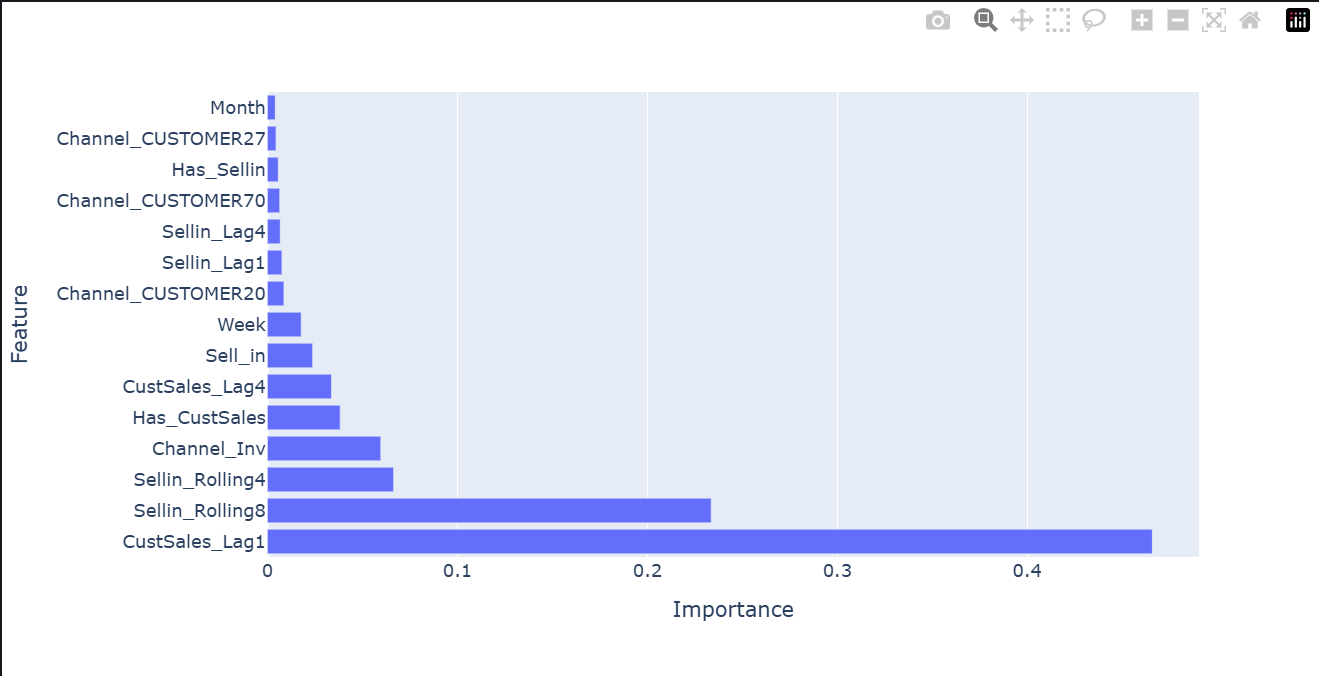


In [120]:
# Tratamiento de valores faltantes
print("Cantidad de datos nulos: ", df_total.isnull().sum().sum())
df_model = df_total.dropna().copy()

features = [
    "Channel",
    "Product_Type",
    "Week",
    "Month",
    "Quarter",
    "Year",
    "Channel_Inv",
    "Sellin_Lag1",
    "Sellin_Lag4",
    "CustSales_Lag1",
    "CustSales_Lag4",
    "Sellin_Rolling4",
    "Sellin_Rolling8"
]

# Codificación de variables categóricas
# NO se incluye Material Description por generar miles de categorías únicas, lo que complicaría el modelado.
df_model = pd.get_dummies(
    df_model,
    columns=[
        "Channel",
        "Product_Type"
    ],
    drop_first=True
)

Cantidad de datos nulos:  374022


### 11.5 División Temporal

In [121]:
# Entrenamiento 2023-2024
train = df_model[df_model["Year"] < 2025]

# Prueba 2025
test = df_model[df_model["Year"] == 2025]

In [123]:
# Construcción de matrices de características y vectores objetivo para entrenamiento y prueba

X_train = train.drop(
    columns=[
        "Cust_Sales",
        "Date",
        "Material Description",
        "High_Cust_Flag",
        "High_Channel_Flag",
        "High_Sellin_Flag",
        "Sell_in"
    ]
)

y_train = train["Cust_Sales"]

X_test = test.drop(
    columns=[
        "Cust_Sales",
        "Date",
        "Material Description","High_Cust_Flag",
        "High_Channel_Flag",
        "High_Sellin_Flag",
        "Sell_in"
    ]
)

y_test = test["Cust_Sales"]

In [124]:
print(X_train.shape)
print(X_test.shape)

(1033800, 186)
(366844, 186)


### 11.6 Modelo Base: Regresión Lineal

In [125]:
# Construir baseline con regresión lineal
model_lr = LinearRegression()

model_lr.fit(
    X_train,
    y_train
)

pred_lr = model_lr.predict(X_test)

In [126]:
# Evaluar el modelo
mae = mean_absolute_error(
    y_test,
    pred_lr
)

rmse = root_mean_squared_error(
    y_test,
    pred_lr,

)

r2 = r2_score(
    y_test,
    pred_lr
)

print(mae)
print(rmse)
print(r2)

5.776093560051465
43.691388053667495
0.3751870345535149


### 11.7 Árbol de Decisión

In [127]:
dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

pred_dt = dt.predict(X_test)

In [128]:
dt_mae = mean_absolute_error(
    y_test,
    pred_dt
)

dt_rmse = root_mean_squared_error(
    y_test,
    pred_dt
)

dt_r2 = r2_score(
    y_test,
    pred_dt
)

print(dt_mae)
print(dt_rmse)
print(dt_r2)

3.700032791327233
45.28975418716165
0.32863565091420865


### 11.8 Random Forest

In [129]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

In [130]:
rf_mae = mean_absolute_error(
    y_test,
    pred_rf
)

rf_rmse = root_mean_squared_error(
    y_test,
    pred_rf,
)

rf_r2 = r2_score(
    y_test,
    pred_rf
)
print(rf_mae)
print(rf_rmse)
print(rf_r2)

3.473112312144153
38.99625837976992
0.5022580705161317


### 11.9 XGBoost

In [131]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

pred_xgb = xgb.predict(
    X_test
)

In [132]:
xgb_mae = mean_absolute_error(
    y_test,
    pred_xgb
)

xgb_rmse = root_mean_squared_error(
    y_test,
    pred_xgb,
)

xgb_r2 = r2_score(
    y_test,
    pred_xgb
)
print(xgb_mae)
print(xgb_rmse)
print(xgb_r2)

3.7859764099121094
39.9157829284668
0.4785080552101135


### 11.10 Comparación de Modelos

<br>
Como es una regresión se manejan las siguientes métricas de evaluación.

- Error absoluto medio MAE.
- Raíz del error cuadrático medio RMSE.
- $R^2$ Coeficiente de determinación.

In [133]:
results = pd.DataFrame({
    "Modelo":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE":[
        mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE":[
        rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2":[
        r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Modelo,MAE,RMSE,R2
0,Linear Regression,5.776094,43.691388,0.375187
1,Decision Tree,3.700033,45.289754,0.328636
2,Random Forest,3.473112,38.996258,0.502258
3,XGBoost,3.785976,39.915783,0.478508


Los resultados obtenidos muestran diferencias importantes en la capacidad predictiva de los modelos evaluados.

La Regresión Lineal presentó el `menor desempeño general`, obteniendo un `R² de 0.375`. Esto indica que las relaciones existentes entre las variables explicativas y las ventas no pueden ser representadas adecuadamente mediante una relación lineal simple. Asimismo, presentó `los mayores errores MAE y RMSE`, evidenciando limitaciones para capturar la complejidad del comportamiento de la demanda.

El Árbol de Decisión logró una mejora respecto a la regresión lineal, alcanzando un `R² de 0.328`. Sin embargo, su capacidad de generalización continúa siendo limitada debido a que construye una única estructura de decisión, lo que puede dificultar la captura de patrones complejos presentes en grandes volúmenes de datos.

El modelo XGBoost obtuvo un `R² de 0.478`, mostrando un desempeño superior a los modelos anteriores. Su capacidad para modelar relaciones no lineales y combinar múltiples árboles permitió capturar una mayor proporción de la variabilidad de las ventas futuras. No obstante, su desempeño fue ligeramente inferior al obtenido por Random Forest.

Por su parte, `Random Forest` presentó el `mejor desempeño global entre los modelos evaluados`, alcanzando un `R² de 0.502`, un MAE de 3.47 y un RMSE de 38.99. Estos resultados indican que aproximadamente el 50% de la variabilidad observada en las ventas puede ser explicada por las variables incluidas en el modelo. Considerando la naturaleza altamente dispersa del conjunto de datos, caracterizado por una elevada proporción de registros con valor cero y una gran heterogeneidad entre clientes y productos, `este resultado puede considerarse satisfactorio para fines de pronóstico de demanda`.

Adicionalmente, durante el desarrollo del proyecto se eliminaron variables derivadas como High_Cust_Flag, High_Channel_Flag y High_Sellin_Flag, debido a que podían introducir problemas de fuga de información (data leakage). Aunque esta decisión redujo parcialmente el desempeño de los modelos, permitió obtener estimaciones más realistas y representativas de la capacidad predictiva real que tendría el sistema en un escenario operativo.

En consecuencia, `se selecciona Random Forest como modelo final del proyecto` debido a que presentó el mejor equilibrio entre capacidad predictiva, estabilidad y generalización sobre datos no observados.


Debido al gran tamaño de la muestra (más de un millón de registros de entrenamiento) y al número relativamente reducido de variables predictoras, el R² ajustado presenta diferencias mínimas respecto al R² tradicional. Por esta razón, se reportan las métricas estándar MAE, RMSE y R² utilizadas habitualmente en problemas de predicción numérica mediante Machine Learning.


Si bien existe margen de mejora mediante la incorporación de variables externas como promociones, campañas comerciales, indicadores económicos o información de precios, los resultados obtenidos demuestran que los patrones históricos de ventas, despachos e inventarios contienen información suficiente para generar predicciones útiles para la planeación comercial y de abastecimiento.

#### Error Promedio de Predicción

El modelo Random Forest obtuvo un error absoluto medio de aproximadamente `3.47 unidades por observación`.

Esto significa que, en promedio, las predicciones realizadas difieren en aproximadamente tres a cuatro unidades respecto al valor real observado.

Desde una perspectiva operativa, este nivel de error puede considerarse aceptable dada la alta dispersión y la gran cantidad de registros sin movimiento presentes en el conjunto de datos.

### 11.11 Indicadores de Negocio

In [161]:
df_pred = df_total.copy()

df_pred = pd.get_dummies(
    df_pred,
    columns=["Channel", "Product_Type"],
    drop_first=True
)


df_pred = df_pred.reindex(columns=X_train.columns, fill_value=0)

In [162]:
df_pred["Pred_Cust_Sales"] = rf.predict(df_pred)
df_pred["Channel_raw"] = df_total["Channel"]
df_pred["Product_Type_raw"] = df_total["Product_Type"]

#### 11.11.1 Productos con Mayor Demanda Proyectada

In [186]:

product_future = (
    df_pred.groupby("Product_Type_raw")["Pred_Cust_Sales"]
    .sum()
    .reset_index()
    .sort_values("Pred_Cust_Sales", ascending=False)
)

fig = px.bar(
    product_future.head(10),
    x="Product_Type_raw",
    y="Pred_Cust_Sales",
    title="Top Productos con Mayor Demanda Proyectada",
    text="Pred_Cust_Sales"
)

fig.show()
product_future.head(10)

,Product_Type_raw,Pred_Cust_Sales
46,MOBILE,5.537415e+06
35,LED TV,1.033965e+06
52,OWM,4.111040e+05
69,TABLET,3.272098e+05
56,QLED TV,2.959289e+05
63,RTF,1.777043e+05
5,AV RECEIVER,1.689046e+05
34,LED MON,1.627756e+05
48,MWO(COMMON),1.277811e+05
23,FWM,1.222016e+05


Los resultados evidencian una fuerte concentración de la demanda en el producto MOBILE, el cual supera ampliamente al resto del portafolio con una proyección de ventas significativamente superior. En segundo nivel se encuentran categorías como LED TV, OWM, TABLET y QLED TV, que mantienen una participación relevante dentro del volumen total proyectado.

Este comportamiento confirma que la demanda del negocio está altamente concentrada en un conjunto reducido de productos, lo cual sugiere la necesidad de priorizar su abastecimiento y disponibilidad en inventario para evitar posibles riesgos de ruptura de stock.

In [169]:
product_forecast = (
    df_pred
    .groupby([col for col in df_pred.columns if "Product_Type_" in col] + ["Pred_Cust_Sales"])
    ["Pred_Cust_Sales"]
    .sum()
    .sort_values(ascending=False)
)

In [170]:
channel_cols = [c for c in df_pred.columns if "Channel_" in c]

customer_risk = df_pred.groupby(channel_cols)["Pred_Cust_Sales"].sum()

low_activity = customer_risk.sort_values().head(10)


In [171]:
priority_table = df_pred.groupby(
    [c for c in df_pred.columns if "Channel_" in c] +
    [c for c in df_pred.columns if "Product_Type_" in c]
)["Pred_Cust_Sales"].sum().reset_index()

priority_table = priority_table.sort_values("Pred_Cust_Sales", ascending=False)

C:\Users\mono1\AppData\Local\Temp\ipykernel_24936\472816950.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  )["Pred_Cust_Sales"].sum().reset_index()


In [172]:
df_pred["Channel_raw"] = df_total["Channel"]
df_pred["Product_Type_raw"] = df_total["Product_Type"]

human_view = (
    df_pred.groupby(["Channel_raw", "Product_Type_raw"])["Pred_Cust_Sales"]
    .sum()
    .reset_index()
    .sort_values("Pred_Cust_Sales", ascending=False)
)


#### 11.11.2 Clientes con Menor Demanda Proyectada 

In [185]:
customer_future = (
    df_pred.groupby("Channel_raw")["Pred_Cust_Sales"]
    .sum()
    .reset_index()
    .sort_values("Pred_Cust_Sales", ascending=True)
)

fig = px.bar(
    customer_future.head(10),
    x="Channel_raw",
    y="Pred_Cust_Sales",
    title="Clientes con Menor Demanda Proyectada (Riesgo de Baja Actividad)",
    text="Pred_Cust_Sales"
)

fig.show()
customer_future.head(10)

,Channel_raw,Pred_Cust_Sales
54,CUSTOMER59,-40.126392
22,CUSTOMER3,-18.289457
50,CUSTOMER55,-15.907897
72,CUSTOMER75,-12.540414
20,CUSTOMER28,-7.391548
81,CUSTOMER83,-6.964478
91,CUSTOMER92,-6.748805
94,CUSTOMER95,-6.155391
33,CUSTOMER4,-3.695774
97,CUSTOMER98,-2.886384


Se observa la existencia de clientes con valores negativos o cercanos a cero en la demanda proyectada, destacándose CUSTOMER59, CUSTOMER3 y CUSTOMER55 como los de menor actividad esperada.

Este comportamiento indica una baja contribución futura al volumen de ventas, lo cual puede interpretarse como un grupo de clientes con bajo nivel de interacción comercial. Desde una perspectiva de negocio, estos clientes pueden ser considerados de baja prioridad operativa o candidatos a estrategias de reactivación comercial.

#### 11.11.3 Tendencia Promedio de Demanda por Producto

In [184]:
product_trend = (
    df_pred.groupby("Product_Type_raw")["Pred_Cust_Sales"]
    .mean()
    .reset_index()
    .sort_values("Pred_Cust_Sales", ascending=False)
)

fig = px.bar(
    product_trend.head(10),
    x="Product_Type_raw",
    y="Pred_Cust_Sales",
    title="Tendencia Promedio de Demanda por Producto",
    text="Pred_Cust_Sales"
)

fig.show()
product_trend.head(10)

,Product_Type_raw,Pred_Cust_Sales
34,LED MON,12.988795
46,MOBILE,11.853155
70,TWM,10.568949
52,OWM,7.616423
44,MINI COMPONENT,4.707035
69,TABLET,4.263209
48,MWO(COMMON),4.207756
35,LED TV,4.105710
23,FWM,3.615433
5,AV RECEIVER,3.035669


El análisis de tendencia promedio confirma nuevamente el dominio de MOBILE como el producto con mayor nivel de demanda esperada, seguido por LED MON, TWM y OWM.

A diferencia del análisis de volumen total, esta gráfica permite observar el comportamiento promedio por categoría, evidenciando que algunos productos mantienen una demanda relativamente constante, mientras que otros presentan menor dinamismo. Esto sugiere la existencia de productos con potencial de crecimiento moderado dentro del portafolio.

#### 11.11.4 Clientes con Menor Tendencia de Ventas

In [183]:
customer_trend = (
    df_pred.groupby("Channel_raw")["Pred_Cust_Sales"]
    .mean()
    .reset_index()
    .sort_values("Pred_Cust_Sales", ascending=True)
)

fig = px.bar(
    customer_trend.head(10),
    x="Channel_raw",
    y="Pred_Cust_Sales",
    title="Clientes con Menor Tendencia de Ventas",
    text="Pred_Cust_Sales"
)

fig.show()
customer_trend.head(10)

,Channel_raw,Pred_Cust_Sales
54,CUSTOMER59,-0.004566
97,CUSTOMER98,-0.003469
94,CUSTOMER95,-0.003382
81,CUSTOMER83,-0.003348
72,CUSTOMER75,-0.003215
22,CUSTOMER3,-0.003113
20,CUSTOMER28,-0.003090
0,CUSTOMER1,-0.003090
40,CUSTOMER46,-0.003090
50,CUSTOMER55,-0.003090


Los clientes identificados en esta gráfica presentan valores promedio de demanda muy bajos o negativos, lo cual refuerza el comportamiento observado en el análisis anterior. Clientes como CUSTOMER59, CUSTOMER98 y CUSTOMER95 muestran una tendencia sostenida de baja actividad comercial.

Este patrón es consistente con una segmentación de clientes de bajo valor dentro del sistema, lo que sugiere la necesidad de evaluar estrategias diferenciadas para este grupo o su posible baja prioridad en la asignación de recursos.

#### 11.11.5 Demanda Proyectada de Cliente vs Producto

In [182]:
priority = (
    df_pred.groupby(["Channel_raw", "Product_Type_raw"])["Pred_Cust_Sales"]
    .sum()
    .reset_index()
    .sort_values("Pred_Cust_Sales", ascending=False)
)

fig = px.scatter(
    priority.head(100),
    x="Channel_raw",
    y="Product_Type_raw",
    size="Pred_Cust_Sales",
    color="Pred_Cust_Sales",
    title="Matriz de Prioridad: Cliente vs Producto (Demanda Proyectada)"
)

fig.show()
priority.head(20)

,Channel_raw,Product_Type_raw,Pred_Cust_Sales
169,CUSTOMER20,MOBILE,1.939240e+06
187,CUSTOMER24,MOBILE,4.478838e+05
1000,CUSTOMER7,MOBILE,4.048670e+05
476,CUSTOMER42,MOBILE,3.727829e+05
984,CUSTOMER69,MOBILE,2.715761e+05
1033,CUSTOMER70,MOBILE,2.563920e+05
474,CUSTOMER42,LED TV,2.414328e+05
210,CUSTOMER27,MOBILE,2.128160e+05
189,CUSTOMER25,MOBILE,1.934120e+05
998,CUSTOMER7,LED TV,1.588256e+05


La matriz de prioridad evidencia una fuerte concentración de la demanda en combinaciones específicas de cliente-producto. En particular, el cliente CUSTOMER20 destaca como el principal generador de demanda, especialmente en el producto MOBILE, donde alcanza los valores más altos del conjunto analizado.

Asimismo, clientes como CUSTOMER24, CUSTOMER7 y CUSTOMER42 también presentan niveles elevados de demanda en productos clave como MOBILE y LED TV. Esto confirma la existencia de clientes estratégicos cuya actividad tiene un impacto significativo en el volumen total del negocio.

Este tipo de análisis permite identificar relaciones críticas cliente-producto, fundamentales para la planificación de inventarios y la priorización de abastecimiento.

### 11.12 Importancia de Variables

In [134]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

fig = px.bar(
    importance.head(15),
    x="Importance",
    y="Feature",
    orientation="h"
)
fig.show()
importance.head(15)

,Feature,Importance
10,CustSales_Lag1,0.465434
13,Sellin_Rolling8,0.236522
12,Sellin_Rolling4,0.068097
2,Channel_Inv,0.064757
11,CustSales_Lag4,0.038684
6,Has_CustSales,0.037809
0,Week,0.017595
5,Has_Sellin,0.013758
25,Channel_CUSTOMER20,0.009139
8,Sellin_Lag1,0.007677


#### Interpretación de Importancia de Variables
Los resultados muestran que las variables históricas poseen la mayor capacidad explicativa dentro del modelo.

La variable más importante fue CustSales_Lag1, seguida por Sellin_Rolling8, Sellin_Rolling4 y Channel_Inv. Esto indica que el comportamiento reciente de las ventas y los despachos constituye el principal predictor de la demanda futura.

Asimismo, algunas variables asociadas al cliente específico también presentan relevancia dentro del modelo, evidenciando que existen diferencias importantes entre canales de distribución.

Estos resultados son consistentes con las hipótesis validadas previamente, donde se encontró evidencia de influencia temporal y diferencias significativas entre clientes.

### 11.13 Predicciones vs Valores Reales

In [135]:
comparison = pd.DataFrame({
    "Real": y_test.values[:300],
    "Predicho": pred_rf[:300]
})

fig = px.line(
    comparison,
    y=["Real","Predicho"],
    title="Comparación entre valores reales y predichos"
)

fig.show()
comparison[276:291]

,Real,Predicho
276,0,-0.003090
277,2,5.489069
278,0,-0.036640
279,1,5.489069
280,3,5.489069
281,11,5.462363
282,2,10.167323
283,5,5.500860
284,5,5.534957
285,3,4.160081


#### Análisis de Predicciones
La comparación entre valores reales y predichos muestra que el modelo logra capturar adecuadamente la tendencia general de las ventas observadas.

No obstante, se identifican diferencias en algunos picos de demanda, donde el modelo tiende a suavizar valores extremos. Este comportamiento es común en modelos basados en árboles debido a que priorizan la generalización sobre la memorización de observaciones particulares.

A pesar de estas diferencias, las predicciones mantienen una tendencia consistente con el comportamiento real de la serie.

### 11.14 Segmentación de Clientes (Clustering)

In [140]:
customer_cluster = (
    df_total
    .groupby("Channel")
    .agg({
        "Sell_in":"sum",
        "Cust_Sales":"sum",
        "Channel_Inv":"mean"
    })
)

In [141]:
scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    customer_cluster
)

In [142]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer_cluster["Cluster"] = (
    kmeans.fit_predict(X_cluster)
)

In [139]:
customer_cluster.groupby("Cluster").mean()

fig = px.scatter(
    customer_cluster,
    x="Sell_in",
    y="Cust_Sales",
    color="Cluster",
    size="Channel_Inv",
    hover_name=customer_cluster.index,
    title="Segmentación de Clientes"
)

fig.show()

customer_cluster

,Sell_in,Cust_Sales,Channel_Inv,Cluster
Channel,,,,
CUSTOMER1,0,0,0.000000,1
CUSTOMER10,7186,7123,8.193269,1
CUSTOMER11,1743,2138,4.686563,1
CUSTOMER12,1044,586,2.283777,1
CUSTOMER13,4375,4432,5.537912,1
...,...,...,...,...
CUSTOMER94,1591,2120,4.561510,1
CUSTOMER95,419,0,0.000000,1
CUSTOMER96,2868,3330,7.516632,1


In [146]:
proportion = customer_cluster["Cluster"].value_counts(normalize=True) * 100
proportion = proportion.reset_index()
proportion.columns = ["Cluster", "Proportion"]
fig = px.bar(
    proportion,
    x="Cluster",
    y="Proportion",
    text_auto='.2f',
    title="Proporción de Clientes por Segmento",
    color="Cluster",
    color_discrete_sequence=px.colors.qualitative.Plotly
)
fig.update_layout(showlegend=False)
fig.show() 
proportion

,Cluster,Proportion
0,1,80.612245
1,3,15.306122
2,0,3.061224
3,2,1.020408


#### Interpretación de Clusters
Los resultados del proceso de clustering permiten identificar grupos diferenciados de clientes en función de su comportamiento de ventas, despachos e inventario. La segmentación evidencia la existencia de un grupo mayoritario compuesto por clientes con bajos niveles de actividad comercial, caracterizados por valores reducidos en sell-in y ventas al cliente final.

Adicionalmente, se identifican clusters con mayor nivel de participación dentro del negocio, los cuales concentran volúmenes significativamente superiores de ventas e inventario. Estos clientes representan los principales generadores de demanda dentro del sistema y presentan un comportamiento más estable y predecible.

También se observa la presencia de un grupo reducido de clientes con alta actividad, los cuales pueden considerarse estratégicos debido a su impacto en el volumen total de ventas. Este tipo de segmentación permite diferenciar claramente entre clientes de bajo, medio y alto valor dentro del ecosistema comercial.

#### Implicaciones de negocio

La segmentación obtenida puede ser utilizada como base para la definición de estrategias diferenciadas de gestión comercial y logística. Los clientes pertenecientes a clusters de alto valor pueden ser priorizados en términos de abastecimiento y disponibilidad de inventario, mientras que los clusters de menor actividad pueden ser objetivo de estrategias de optimización de costos o reactivación comercial.

En conjunto, esta segmentación aporta una visión complementaria al modelo predictivo, permitiendo no solo estimar la demanda futura, sino también comprender la estructura del comportamiento de los clientes dentro del negocio.

### 11.15 Conclusiones del Modelado

Los resultados obtenidos demuestran que las ventas futuras pueden ser estimadas utilizando información histórica de despachos, inventarios, variables temporales y comportamiento previo de los clientes.

Entre los modelos evaluados, `Random Forest obtuvo el mejor desempeño predictivo`, alcanzando un R² de 0.502, un MAE de 3.47 y un RMSE de 38.99. Aunque el desempeño disminuyó respecto a versiones iniciales del modelo debido a la eliminación de variables que podían introducir fuga de información, los resultados obtenidos son más representativos de la capacidad predictiva real del sistema.

Adicionalmente, la segmentación mediante clustering permitió identificar grupos de clientes con comportamientos similares, proporcionando información útil para estrategias de abastecimiento, comercialización y gestión de inventarios.

En conjunto, los resultados respaldan la viabilidad de utilizar técnicas de Machine Learning para apoyar la toma de decisiones comerciales dentro del ecosistema Samsung.

### 11.16 Limitaciones

Aunque los modelos obtuvieron resultados satisfactorios, existen algunas limitaciones. El conjunto de datos presenta una `alta proporción de registros con valor cero`, además de información limitada sobre factores externos como campañas comerciales, promociones, precios o condiciones macroeconómicas. La incorporación de estas variables podría mejorar el desempeño predictivo en futuros desarrollos.

# 12. Insights de Negocio

A partir del análisis realizado sobre los datos históricos de ventas, inventarios y comportamiento de clientes, se identifican los siguientes hallazgos relevantes para el entendimiento del negocio y la toma de decisiones estratégicas.

A partir del análisis realizado sobre los datos históricos de ventas, despachos e inventarios, se identifican hallazgos relevantes que permiten comprender el comportamiento del negocio desde una perspectiva operativa y analítica.

En primer lugar, se evidencia que el conjunto de datos presenta una alta densidad de registros sin actividad de venta. En particular, el `79.49%` de los registros corresponden a valores cero en la variable de ventas (Cust_Sales), mientras que en el caso de despachos (Sell_in) este porcentaje asciende al `94.29%`. Este comportamiento indica que el negocio opera bajo un esquema de demanda altamente intermitente, donde una gran proporción de `combinaciones producto-cliente-periodo no presenta movimiento`. **Este tipo de distribución representa un reto importante para la modelación predictiva, pero también refleja una estructura realista de mercado con baja rotación en múltiples segmentos del portafolio**.

En segundo lugar, el análisis de segmentación de clientes evidencia una estructura altamente concentrada. Aproximadamente el `80.6% de los clientes se agrupan en el cluster dominante`, caracterizado por `bajo volumen de ventas y baja actividad operativa`. En contraste, un grupo reducido de clientes concentra una proporción significativamente mayor de la actividad comercial, con clusters que representan el 15.3%, 3.06% y 1.02% del total respectivamente. **Esta distribución confirma un comportamiento tipo Pareto dentro del negocio, donde un número reducido de clientes concentra la mayor parte del valor operativo**.

Adicionalmente, el análisis de concentración por tipo de producto muestra una fuerte dependencia del negocio hacia categorías específicas. Los resultados evidencian que un pequeño subconjunto de productos concentra la mayor parte de la actividad comercial, mientras que la mayoría del portafolio presenta una contribución marginal al volumen total. Por ejemplo, categorías como `MOBILE, LED TV y OWM concentran más del 80% acumulado del volumen`, mientras que productos como RLF o TWM alcanzan contribuciones superiores al 95% en la distribución acumulada. **Este comportamiento refuerza la necesidad de una gestión diferenciada del portafolio de productos, priorizando aquellos de mayor impacto en la demanda total**.

Desde la perspectiva del modelado predictivo, los resultados obtenidos muestran que los modelos basados en ensamble presentan el mejor desempeño para la estimación de la demanda. En particular, `Random Forest alcanza un R² de 0.502, con un MAE de 3.47 y un RMSE de 38.99, lo que indica que el modelo logra explicar aproximadamente el 50% de la variabilidad observada en las ventas`. Aunque este nivel de desempeño no captura completamente la complejidad del sistema, es consistente con la alta variabilidad y la naturaleza dispersa del conjunto de datos.

Asimismo, la comparación entre modelos evidencia que los enfoques lineales presentan limitaciones significativas para capturar la dinámica del negocio, mientras que los modelos no lineales muestran una mejora sustancial en la capacidad predictiva. Este comportamiento confirma la existencia de relaciones complejas entre variables temporales, operativas e históricas dentro del sistema de ventas.

Finalmente, se identifica que `el comportamiento del negocio está fuertemente influenciado por patrones históricos, donde variables rezagadas y promedios móviles tienen un impacto determinante en la predicción de la demanda`. Sin embargo, también se evidencia una **limitación importante derivada de la ausencia de variables externas como promociones, precios o factores macroeconómicos**, lo cual restringe la capacidad explicativa de los modelos desarrollados.

En conjunto, los resultados permiten concluir que el negocio presenta una estructura altamente concentrada, con demanda intermitente y fuerte dependencia del comportamiento histórico, lo cual valida el uso de técnicas de machine learning como herramienta de apoyo para la planificación de inventarios y la toma de decisiones comerciales.

# 13. Respuesastas Estratégicas del Negocio

#### a. Productos con mayor rotación proyectada

El análisis de demanda proyectada muestra que el producto con mayor nivel de rotación futura es MOBILE, con una demanda estimada significativamente superior al resto del portafolio, alcanzando valores por encima de 5.5 millones en la agregación total. Este comportamiento indica que el segmento de dispositivos móviles representa el principal motor de demanda dentro del negocio.

En un segundo nivel se encuentran productos como LED TV, OWM, TABLET y QLED TV, los cuales también presentan volúmenes relevantes de demanda proyectada, aunque considerablemente menores en comparación con MOBILE. Esto confirma una estructura de demanda altamente concentrada en un conjunto reducido de categorías tecnológicas.

#### b. Clientes con tendencia a baja actividad (riesgo operativo)

El análisis de clientes con menor demanda proyectada evidencia que ciertos clientes presentan valores negativos o cercanos a cero en la predicción de ventas, lo cual indica una tendencia de baja actividad dentro del modelo.

Entre ellos se destacan clientes como CUSTOMER59, CUSTOMER3, CUSTOMER55 y CUSTOMER75, los cuales presentan los valores más bajos dentro del conjunto analizado. Este comportamiento sugiere que estos clientes tienen una contribución marginal al volumen total del negocio y podrían representar cuentas con bajo potencial de actividad futura.

Desde una perspectiva estratégica, estos clientes pueden ser considerados como cuentas en riesgo de baja participación, lo cual permite priorizar esfuerzos comerciales o revisar su relación con el negocio.

#### c. Productos con mayor tendencia de crecimiento

El análisis de tendencia promedio de demanda por producto muestra nuevamente a MOBILE como el principal producto con crecimiento esperado, seguido por categorías como LED MON, TWM y OWM.

En particular, LED MON presenta un comportamiento destacado dentro del análisis de tendencia, lo que sugiere un posible crecimiento relativo dentro de su segmento específico. Esto indica que, además del dominio absoluto de MOBILE, existen categorías que podrían presentar oportunidades de expansión o consolidación en el mediano plazo.

#### d. Clientes con menor tendencia de ventas

En términos de tendencia de ventas, se observa que los mismos clientes identificados como de baja actividad presentan valores promedio negativos o cercanos a cero en su comportamiento proyectado.

Clientes como CUSTOMER59, CUSTOMER98, CUSTOMER95 y CUSTOMER83 presentan las menores tendencias de ventas, lo que refuerza la identificación de un grupo reducido de clientes con baja participación en el sistema comercial.

Este comportamiento es consistente con la segmentación previa, donde se identifican clusters de baja actividad que concentran una proporción reducida del volumen total de ventas

#### e. Priorización de clientes y productos (matriz cliente–producto)

El análisis de la matriz de prioridad cliente–producto permite identificar las combinaciones con mayor impacto en la demanda proyectada.

Se evidencia que el cliente CUSTOMER20 es el principal actor dentro del sistema, con una demanda proyectada significativamente superior al resto, especialmente en el producto MOBILE, donde alcanza valores cercanos a 1.9 millones. Este resultado confirma su rol como cliente estratégico dentro del negocio.

De manera consistente, otros clientes como CUSTOMER24, CUSTOMER7 y CUSTOMER42 también presentan niveles elevados de demanda proyectada, principalmente asociados a productos como MOBILE y LED TV.

Este comportamiento indica una fuerte concentración de la demanda en un grupo reducido de clientes clave, lo cual refuerza la necesidad de implementar estrategias diferenciadas de abastecimiento y gestión comercial. En particular, estos clientes deben ser priorizados en términos de disponibilidad de inventario y continuidad operativa, debido a su impacto directo en el volumen total de ventas.

# 14. Conclusiones y Trabajo Futuro

### 15.1 Conclusiones

El presente proyecto permitió desarrollar una solución analítica integral orientada a la predicción de la demanda de productos Samsung a partir de datos históricos de ventas, despachos e inventarios. A través de técnicas de machine learning y segmentación de clientes, se logró transformar información operativa en conocimiento útil para la toma de decisiones estratégicas dentro del negocio.

En términos de modelado predictivo, se evaluaron diferentes enfoques supervisados, incluyendo regresión lineal, árboles de decisión, Random Forest y XGBoost. Entre ellos, el modelo Random Forest obtuvo el mejor desempeño, alcanzando un R² de 0.502, un MAE de 3.47 y un RMSE de 38.99. Estos resultados indican que el modelo es capaz de explicar aproximadamente el 50% de la variabilidad en la demanda, lo cual es consistente con la alta complejidad y dispersión del conjunto de datos analizado.

Adicionalmente, se identificó que la eliminación de variables potencialmente sesgadas o con riesgo de fuga de información redujo ligeramente el desempeño del modelo, pero permitió obtener resultados más realistas y representativos de un escenario operativo real. Esto refuerza la importancia de priorizar la generalización del modelo sobre el ajuste excesivo a los datos históricos.

Por otro lado, la segmentación de clientes mediante técnicas de clustering permitió identificar grupos con diferentes niveles de actividad comercial, destacando un grupo mayoritario de clientes de baja participación y un conjunto reducido de clientes estratégicos con alta contribución al volumen total de ventas. Esta segmentación complementa el modelo predictivo al permitir una visión más estructurada del comportamiento del negocio.

Desde la perspectiva de negocio, los resultados obtenidos permiten identificar patrones claros de concentración tanto en productos como en clientes, evidenciando una fuerte dependencia de categorías específicas como MOBILE y de clientes clave como CUSTOMER20. Este comportamiento representa una oportunidad para optimizar la gestión de inventarios, la asignación de recursos comerciales y la planificación de la demanda.

### 15.2 Trabajo Futuro

Como mejoras y extensiones del presente proyecto, se identifican varias líneas de trabajo:

En primer lugar, la incorporación de variables externas como precios, promociones, campañas comerciales y factores macroeconómicos podría mejorar significativamente la capacidad predictiva del modelo, permitiendo capturar mejor las variaciones en la demanda.

En segundo lugar, se recomienda el desarrollo de modelos de series de tiempo o enfoques híbridos que permitan capturar de manera más explícita la estacionalidad y las tendencias temporales del negocio.

Asimismo, podría implementarse un modelo específico de segmentación de riesgo de clientes (churn analysis), con el objetivo de identificar de manera más precisa aquellos clientes con probabilidad de reducir o abandonar su actividad comercial.

Finalmente, la integración del modelo en un entorno productivo con dashboards interactivos permitiría convertir este desarrollo en una herramienta de apoyo continuo para la toma de decisiones operativas y estratégicas dentro de la organización.